# Librerías

In [ ]:
from google.colab import files
import io

import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Reto 1. Determinación de la población real del destino (demanda efectiva)

Utilizamos el código siguiente que aparece comentado para procesar por primera vez los datos y unificar el turismo receptor, emisor e interno en 3 conjuntos de datos distintos.

In [ ]:
'''
print("Por favor, selecciona los 7 archivos Excel:")
# Esto abrirá el explorador de archivos de tu ordenador
archivos = files.upload()

# Obtener los nombres de los archivos que has subido
archivos_excel = list(archivos.keys())
'''

'\nprint("Por favor, selecciona los 7 archivos Excel:")\n# Esto abrirá el explorador de archivos de tu ordenador\narchivos = files.upload()\n\n# Obtener los nombres de los archivos que has subido\narchivos_excel = list(archivos.keys())\n'

In [ ]:
'''
# Lista donde iremos guardando los fragmentos de datos filtrados por Torrevieja
datos_filtrados = []

for archivo in archivos_excel:
    print(f"Procesando el archivo: {archivo} ...")

    # Leer todas las hojas (sheet_name=None).
    # dtype={'mun_orig_cod': str} fuerza a que se lea como texto para no perder el cero a la izquierda
    try:
        diccionario_hojas = pd.read_excel(archivo, sheet_name=None, dtype={'mun_orig_cod': str})
    except FileNotFoundError:
        print(f"No se encontró el archivo {archivo}.")
        continue

    # Iterar sobre cada hoja del diccionario de este excel
    for nombre_hoja, df in diccionario_hojas.items():
        # Verificamos que la columna existe en la hoja actual para evitar errores
        if 'mun_orig_cod' in df.columns:

            # Aseguramos que es un string y rellenamos con 0 a la izquierda hasta tener 5 caracteres por si acaso
            df['mun_orig_cod'] = df['mun_orig_cod'].astype(str).str.zfill(5)

            # Filtramos los registros
            df_filtrado = df[df['mun_orig_cod'] == '03133'].copy()

            # Si hay resultados en este mes/hoja, los guardamos
            if not df_filtrado.empty:
                datos_filtrados.append(df_filtrado)
        else:
            print(f"  -> Aviso: La columna 'mun_orig_cod' no existe en la hoja '{nombre_hoja}' del archivo '{archivo}'.")

# Finalmente, unificamos todos los DataFrames filtrados en uno solo
if datos_filtrados:
    df = pd.concat(datos_filtrados, ignore_index=True)

    print("\n¡Proceso terminado!")
    print(f"Se han recuperado un total de {len(df)} registros.")

    # Exportar el resultado unificado a un nuevo Excel
    archivo_torrevieja = 'datos_unificados_torrevieja.xlsx'
    df.to_excel(archivo_torrevieja, index=False)
    print(f"Datos guardados correctamente en: {archivo_torrevieja}")

else:
    print("\nNo se encontró ningún registro con el código 03133 en los archivos proporcionados.")
'''

'\n# Lista donde iremos guardando los fragmentos de datos filtrados por Torrevieja\ndatos_filtrados = []\n\nfor archivo in archivos_excel:\n    print(f"Procesando el archivo: {archivo} ...")\n\n    # Leer todas las hojas (sheet_name=None).\n    # dtype={\'mun_orig_cod\': str} fuerza a que se lea como texto para no perder el cero a la izquierda\n    try:\n        diccionario_hojas = pd.read_excel(archivo, sheet_name=None, dtype={\'mun_orig_cod\': str})\n    except FileNotFoundError:\n        print(f"No se encontró el archivo {archivo}.")\n        continue\n\n    # Iterar sobre cada hoja del diccionario de este excel\n    for nombre_hoja, df in diccionario_hojas.items():\n        # Verificamos que la columna existe en la hoja actual para evitar errores\n        if \'mun_orig_cod\' in df.columns:\n\n            # Aseguramos que es un string y rellenamos con 0 a la izquierda hasta tener 5 caracteres por si acaso\n            df[\'mun_orig_cod\'] = df[\'mun_orig_cod\'].astype(str).str.zfill

In [ ]:
# files.download('datos_unificados_torrevieja.xlsx')

### Carga de datos

Hay que seleccionar todos los archivos de la carpeta de datos.

In [ ]:
print("Selecciona TODOS los archivos:")
archivos_subidos = files.upload()

In [ ]:
# --- 1. Turistas Internacionales ---
nombre_int = 'datos_turismo_internacional.xlsx'
if nombre_int in archivos_subidos:
    df_turistas_int = pd.read_excel(io.BytesIO(archivos_subidos[nombre_int]))
    print(f"{nombre_int} cargado correctamente.")
else:
    print(f"No se encontró {nombre_int}")

# --- 2. Turistas Nacionales ---
nombre_nac = 'datos_turismo_nacional.xlsx'
if nombre_nac in archivos_subidos:
    df_turistas_nac = pd.read_excel(io.BytesIO(archivos_subidos[nombre_nac]))
    print(f"{nombre_nac} cargado correctamente.")
else:
    print(f"No se encontró {nombre_nac}")

# --- 3. Turismo Emisor ---
nombre_emi = 'datos_turismo_emisor.xlsx'
if nombre_emi in archivos_subidos:
    df_turistas_emi = pd.read_excel(io.BytesIO(archivos_subidos[nombre_emi]))
    print(f"{nombre_emi} cargado correctamente.")
else:
    print(f"No se encontró {nombre_emi}")

# --- 4. Residentes ---
nombre_res = 'datos_censo.csv'
if nombre_res in archivos_subidos:
    df_residentes = pd.read_csv(io.BytesIO(archivos_subidos[nombre_res]), sep=";", encoding="latin1", skiprows=3)
    print(f"{nombre_res} cargado correctamente.")
else:
    print(f"No se encontró {nombre_res}")

Vamos a cargar aquí unos datos de pernoctaciones medias de la provincia de Alicante que nos servirán una vez para determinar la media de población real en cada instante en Torrevieja.

In [ ]:
uploaded = files.upload()

Saving pernoctaciones_emi.csv to pernoctaciones_emi.csv
Saving pernoctaciones_inter.csv to pernoctaciones_inter.csv
Saving pernoctaciones_nac.csv to pernoctaciones_nac.csv


In [ ]:
df_inter = pd.read_csv('pernoctaciones_inter.csv', sep=';', encoding='latin-1')
df_nac = pd.read_csv('pernoctaciones_nac.csv', sep=';', encoding='latin-1')
df_emi = pd.read_csv('pernoctaciones_emi.csv', sep=';', encoding='latin-1')

def procesar_dataset(df):
    # Filtramos por Concepto turístico
    df_filtrado = df[df['Concepto turístico'] == 'Duración media de los viajes'].copy()

    # Pasamos Periodo a datetime
    df_filtrado['Periodo'] = pd.to_datetime(df_filtrado['Periodo'], format='%YM%m')

    df_filtrado['Total'] = df_filtrado['Total'].astype(str)
    df_filtrado['Total'] = df_filtrado['Total'].str.replace('.', '', regex=False)
    df_filtrado['Total'] = df_filtrado['Total'].str.replace(',', '.', regex=False)
    df_filtrado['Total'] = pd.to_numeric(df_filtrado['Total'], errors='coerce')

    df_filtrado = df_filtrado[['Periodo', 'Total']]

    # Creamos la columna 'Valor': días del mes / Total
    df_filtrado['Valor'] = df_filtrado['Periodo'].dt.days_in_month / df_filtrado['Total']

    return df_filtrado

df_inter_final = procesar_dataset(df_inter)
df_nac_final = procesar_dataset(df_nac)
df_emi_final = procesar_dataset(df_emi)

# Visualizamos los resultados
print("Dataset Internacional procesado:")
display(df_inter_final.head())

Dataset Internacional procesado:


,Periodo,Total,Valor
156,2025-12-01,10.0,3.100000
157,2025-11-01,8.9,3.370787
158,2025-10-01,8.2,3.780488
159,2025-09-01,8.0,3.750000
160,2025-08-01,9.3,3.333333


### Preparación e integración de datos

#### Para datos de turismo:

In [ ]:
df_turistas_int['fecha'] = pd.to_datetime(df_turistas_int['mes'])
df_turistas_nac['fecha'] = pd.to_datetime(df_turistas_nac['mes'])
df_turistas_emi['fecha'] = pd.to_datetime(df_turistas_emi['mes'])

In [ ]:
df_turistas_int['fecha'] = pd.to_datetime(df_turistas_int['fecha'])
df_turistas_nac['fecha'] = pd.to_datetime(df_turistas_nac['fecha'])
df_turistas_emi['fecha'] = pd.to_datetime(df_turistas_emi['fecha'])

def unir_y_calcular(df_turistas, df_valor_referencia):
    df_resultado = pd.merge(
        df_turistas,
        df_valor_referencia[['Periodo', 'Valor']],
        left_on='fecha',
        right_on='Periodo',
        how='left'
    )

    if df_resultado['turistas'].dtype == object:  # Si es texto
        df_resultado['turistas'] = df_resultado['turistas'].str.replace('.', '', regex=False)
        df_resultado['turistas'] = df_resultado['turistas'].str.replace(',', '.', regex=False)

    df_resultado['turistas'] = pd.to_numeric(df_resultado['turistas'], errors='coerce')

    # Calculamos la nueva columna: turistas / Valor
    df_resultado['turistas_reales'] = (df_resultado['turistas'] / df_resultado['Valor']).round(0)

    # Eliminamos la columna 'Periodo' que se duplicó al hacer el merge
    return df_resultado.drop(columns=['Periodo'])

df_turistas_int = unir_y_calcular(df_turistas_int, df_inter_final)
df_turistas_nac = unir_y_calcular(df_turistas_nac, df_nac_final)
df_turistas_emi = unir_y_calcular(df_turistas_emi, df_emi_final)

# Verificamos el resultado
print("Muestra del DataFrame Internacional con turistas_reales:")
display(df_turistas_int[['fecha', 'turistas', 'Valor', 'turistas_reales']].head())

Muestra del DataFrame Internacional con turistas_reales:


,fecha,turistas,Valor,turistas_reales
0,2019-07-01,67182,4.078947,16470.0
1,2019-07-01,65658,4.078947,16097.0
2,2019-07-01,36612,4.078947,8976.0
3,2019-07-01,653,4.078947,160.0
4,2019-07-01,507,4.078947,124.0


#### Para datos de censo:

In [ ]:
# Quitamos las columnas que no queremos
df_residentes = df_residentes.iloc[0,5:12]

# Añadimos una fila que sea
df_residentes = pd.DataFrame({
    'Personas': df_residentes.values,
    'Año': list(range(2025, 2018, -1))  # 2025, 2024, ..., 2019
})

Añadimos el dato de 2026 que nos faltaba extraído del ayuntamiento de torrevieja:

In [ ]:
df_residentes = pd.concat([pd.DataFrame({'Personas': [104620], 'Año': [2026]}), df_residentes], ignore_index=True)

Cambiamos la fecha a formato datetime y para ello establecemos el año en el 1 de enero de cada uno

In [ ]:
df_residentes['fecha'] = pd.to_datetime(df_residentes['Año'].astype(str) + '-01-01')

### Análisis exploratorio, visualización y minería de datos.

In [ ]:
# Procesado temporal exclusivo para las gráficas
df_res_plot = df_residentes.sort_values('fecha')
df_nac_plot = df_turistas_nac.sort_values('fecha')
df_int_plot = df_turistas_int.sort_values('fecha')
df_emi_plot = df_turistas_emi.sort_values('fecha')

df_int_plot = df_int_plot[df_int_plot['pais_orig'] == 'Total']
df_int_plot = df_int_plot[['fecha', 'turistas', 'turistas_reales']]

df_nac_plot = df_nac_plot.groupby('fecha')[['turistas','turistas_reales']].sum().reset_index()

df_emi_plot = df_emi_plot[df_emi_plot['destino'] == 'Total']
df_emi_plot = df_emi_plot[['fecha', 'turistas', 'turistas_reales']]

,fecha,turistas,turistas_reales
0,2019-07-01,89907,14785.0
1,2019-08-01,127890,30530.0
2,2019-09-01,43201,8361.0
3,2019-10-01,17576,2379.0
4,2019-11-01,14819,1878.0
...,...,...,...
73,2025-08-01,98437,23804.0
74,2025-09-01,34890,7323.0
75,2025-10-01,14081,2183.0
76,2025-11-01,14652,1856.0


Gráfica para mostrar la población real así como los diferentes tipos de turistas y empadronados.

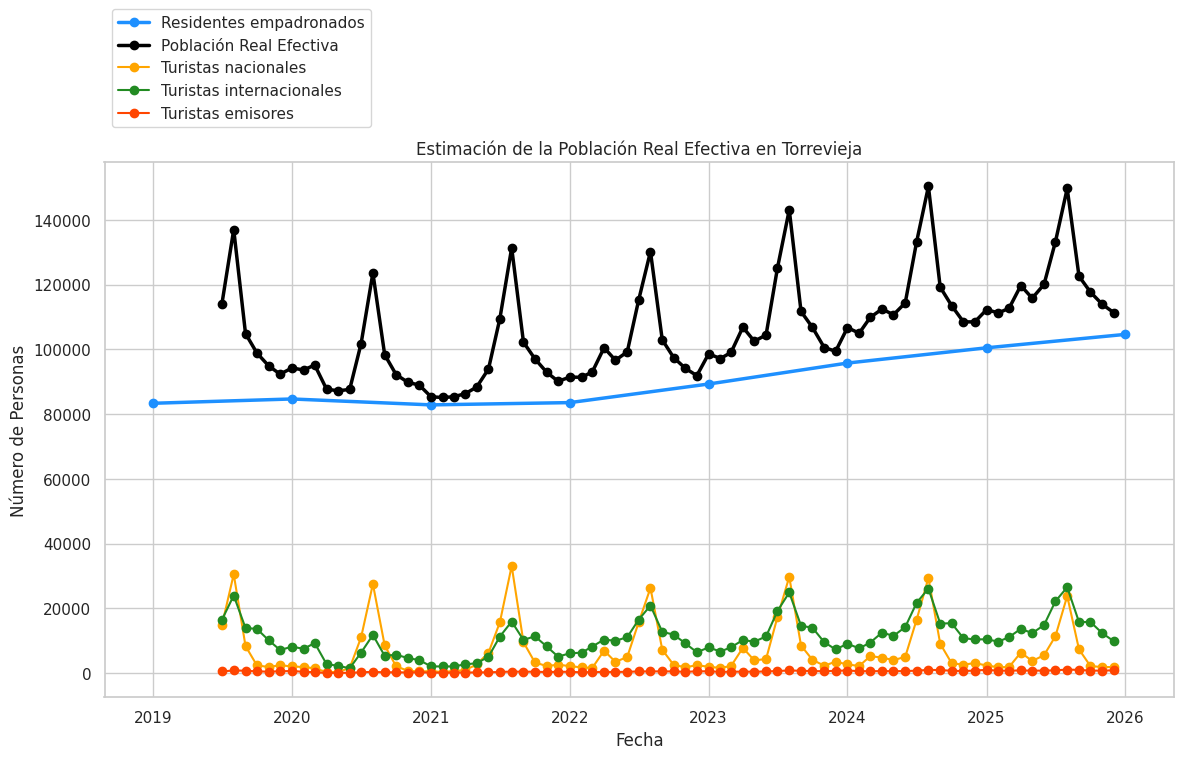

In [ ]:
# Renombramos las columnas de turistas para no confundirlas al unirlas
df_nac_plot = df_nac_plot.rename(columns={'turistas': 'turistas_nac'})
df_int_plot = df_int_plot.rename(columns={'turistas': 'turistas_int'})
df_emi_plot = df_emi_plot.rename(columns={'turistas': 'turistas_emi'})

df_nac_plot = df_nac_plot.rename(columns={'turistas_reales': 'turistas_nac_reales'})
df_int_plot = df_int_plot.rename(columns={'turistas_reales': 'turistas_int_reales'})
df_emi_plot = df_emi_plot.rename(columns={'turistas_reales': 'turistas_emi_reales'})

# Unimos los tres DataFrames de turismo guiándonos por la fecha
df_suma_plot = pd.merge(df_nac_plot, df_int_plot, on='fecha', how='outer')
df_suma_plot = pd.merge(df_suma_plot, df_emi_plot, on='fecha', how='outer')

# Para los residentes, extraemos el año para poder asignarle a cada mes su población base correspondiente
df_suma_plot['Año'] = df_suma_plot['fecha'].dt.year
df_res_plot['Año'] = df_res_plot['fecha'].dt.year

# Añadimos la columna de 'Personas' (Residentes) a nuestro DataFrame total
df_suma_plot = pd.merge(df_suma_plot, df_res_plot[['Año', 'Personas']], on='Año', how='left')

# Calculamos la Población Real
df_suma_plot['poblacion_real'] = (df_suma_plot['Personas'] - df_suma_plot['turistas_emi_reales'] + df_suma_plot['turistas_nac_reales'] + df_suma_plot['turistas_int_reales'])

df_suma_plot = df_suma_plot.sort_values('fecha')

# Generación del gráfico
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

# Destacamos las dos líneas principales: La base de residentes y la población real calculada
plt.plot(df_res_plot['fecha'], df_res_plot['Personas'], marker='o', color='dodgerblue', linewidth=2.5, label='Residentes empadronados')
plt.plot(df_suma_plot['fecha'], df_suma_plot['poblacion_real'], marker='o', color='black', linewidth=2.5, label='Población Real Efectiva')
plt.plot(df_nac_plot['fecha'], df_nac_plot['turistas_nac_reales'], marker='o', color='orange', label='Turistas nacionales')
plt.plot(df_int_plot['fecha'], df_int_plot['turistas_int_reales'], marker='o', color='forestgreen', label='Turistas internacionales')
plt.plot(df_emi_plot['fecha'], df_emi_plot['turistas_emi_reales'], marker='o', color='orangered', label='Turistas emisores')

# Personalización
plt.title("Estimación de la Población Real Efectiva en Torrevieja")
plt.xlabel("Fecha")
plt.ylabel("Número de Personas")
plt.legend(loc='upper left', bbox_to_anchor=(0, 1.3))
plt.grid(True)
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [ ]:
# Descargamos el conjunto de datos de la población real efectiva:

# df_suma_plot.to_csv("df_suma_plot.csv",sep = ";", index=False)

# from google.colab import files
# files.download("df_suma_plot.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Reto 2. Estacionalidad

Gráfica para ver las tendencias de turismo internacional, nacional y emisor.

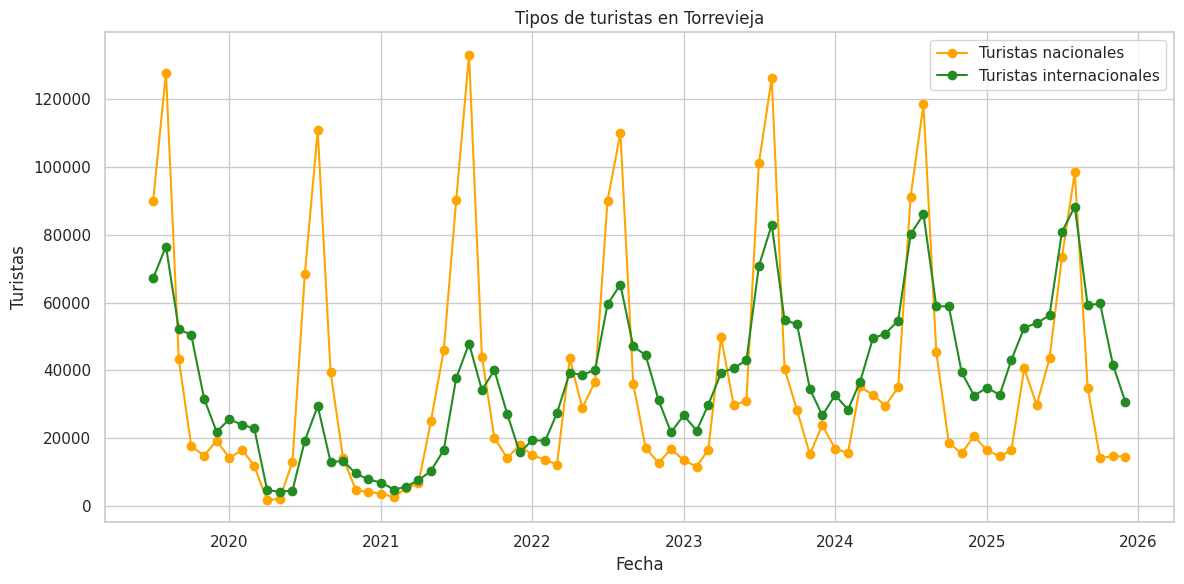

In [ ]:
# Configuramos el estilo y el tamaño
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# Dibujamos las tres líneas
plt.plot(df_nac_plot['fecha'], df_nac_plot['turistas_nac'], marker='o', color='orange', label='Turistas nacionales')
plt.plot(df_int_plot['fecha'], df_int_plot['turistas_int'], marker='o', color='forestgreen', label='Turistas internacionales')
#plt.plot(df_emi_plot['fecha'], df_emi_plot['turistas_emi'], marker='o', color='orangered', label='Turistas emisores')

# Personalización
plt.title("Tipos de turistas en Torrevieja")
plt.xlabel("Fecha")
plt.ylabel("Turistas")
plt.legend(loc='upper right')
plt.grid(True)
#plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar gráfico
plt.show()

Tabla para ver el origen del turismo internacional.

In [ ]:
# Extraemos el mes numérico para poder filtrar
df_turistas_int['mes_num'] = df_turistas_int['fecha'].dt.month

# Filtramos los meses de temporada baja: Ene (1), Feb (2), Oct (10), Nov (11), Dic (12)
meses_baja = [1, 2, 10, 11, 12]
df_temp_baja = df_turistas_int[df_turistas_int['mes_num'].isin(meses_baja)]

# Excluimos la fila donde el país es 'Total' para analizar solo países individuales
df_temp_baja = df_temp_baja[~df_temp_baja['pais_orig'].isin(['Total', 'Total Europa', 'Total Unión Europea', 'Total África', 'Total América', 'Total América del Norte', 'Total Sudamérica', 'Total Asia'])]

# Agrupamos por país y calculamos la media matemática
table_temp_baja = df_temp_baja.groupby('pais_orig')['turistas'].mean().reset_index()

# Renombramos las columnas
table_temp_baja = table_temp_baja.rename(columns={
    'pais_orig': 'País de Origen',
    'turistas': 'Media Mensual (Oct-Feb)'
})

# Ordenamos de mayor a menor volumen de turistas
table_temp_baja = table_temp_baja.sort_values(by='Media Mensual (Oct-Feb)', ascending=False)
table_temp_baja['Media Mensual (Oct-Feb)'] = table_temp_baja['Media Mensual (Oct-Feb)'].round(0).astype(int)

# Reseteamos el índice para que quede una tabla limpia
table_temp_baja = table_temp_baja.reset_index(drop=True)

# Mostramos la tabla final
table_temp_baja.head(10)

,País de Origen,Media Mensual (Oct-Feb)
0,Reino Unido,5348
1,Suecia,4830
2,Noruega,2819
3,Bélgica,2244
4,Alemania,2226
5,Polonia,1769
6,Finlandia,1726
7,Francia,1246
8,Países Bajos,1188
9,Irlanda,1076


Gráfica para estudiar la tendencia del turismo receptor total (internacional + nacional) vs el turismo emisor.

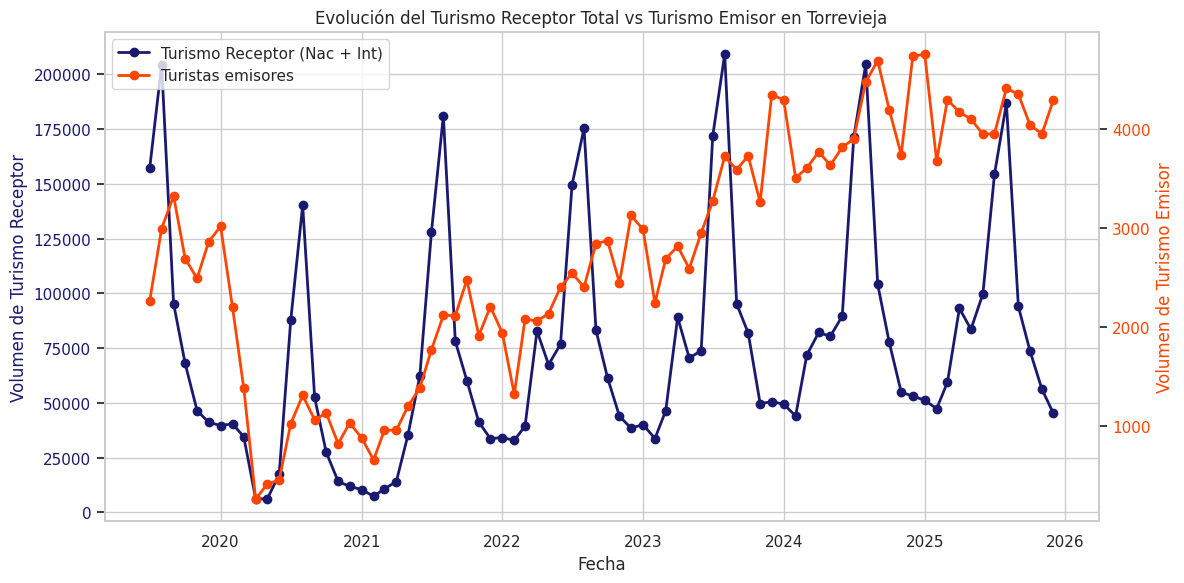

In [ ]:
# Unimos ambos dataframes guiándonos por la fecha
df_receptor = pd.merge(df_nac_plot, df_int_plot, on='fecha', how='outer', suffixes=('_nac', '_int'))

# Sumamos los turistas
df_receptor['turistas_total'] = df_receptor['turistas_nac'] + df_receptor['turistas_int']
df_receptor = df_receptor.sort_values('fecha')

# Configuración del gráfico con doble eje
sns.set(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Suma del turismo receptor
line1 = ax1.plot(df_receptor['fecha'], df_receptor['turistas_total'], marker='o', color='midnightblue', linewidth=2, label='Turismo Receptor (Nac + Int)')
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Volumen de Turismo Receptor", color='midnightblue')
ax1.tick_params(axis='y', labelcolor='midnightblue')

# Turismo emisor
ax2 = ax1.twinx()
line2 = ax2.plot(df_emi_plot['fecha'], df_emi_plot['turistas_emi'], marker='o', color='orangered', linewidth=2, label='Turistas emisores')
ax2.set_ylabel("Volumen de Turismo Emisor", color='orangered')
ax2.tick_params(axis='y', labelcolor='orangered')

# Agrupamos las líneas de ambos ejes en una sola caja de leyenda
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Evolución del Turismo Receptor Total vs Turismo Emisor en Torrevieja")
ax1.grid(True)
ax2.grid(False) # Desactivamos la cuadrícula secundaria para no saturar el fondo

plt.tight_layout()
plt.show()

Gráfica para mostrar el volumen real de personas frente a los empradronados.

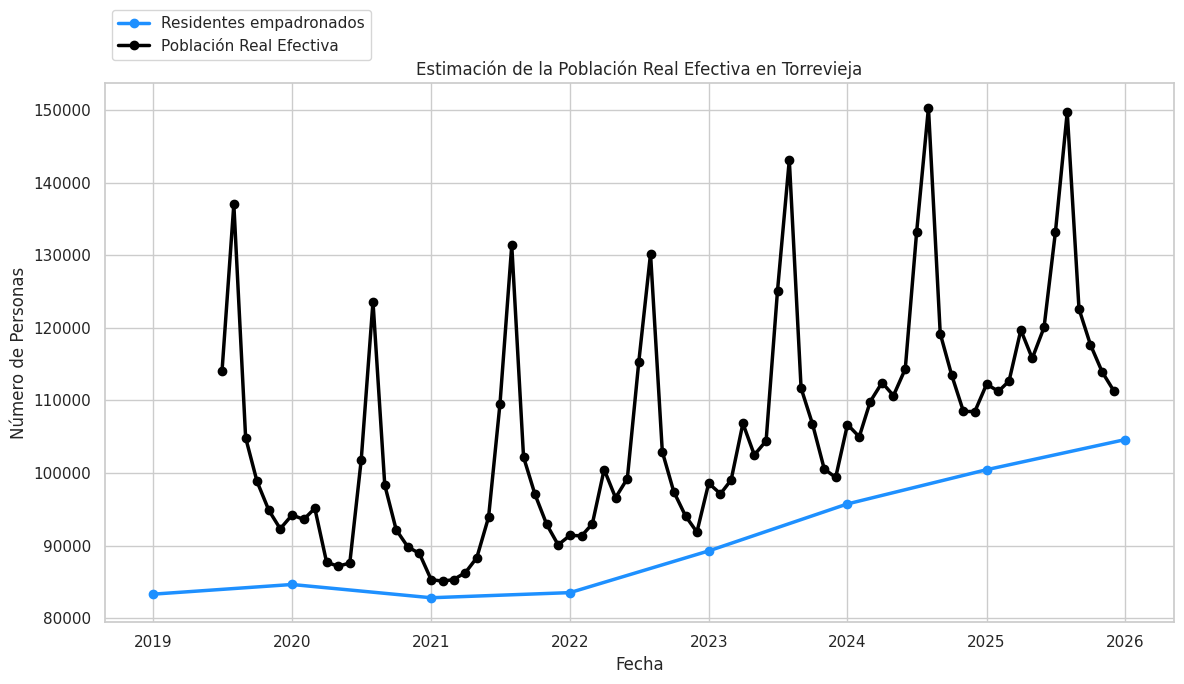

In [ ]:
# Unimos los tres DataFrames de turismo guiándonos por la fecha
df_suma_plot = pd.merge(df_nac_plot, df_int_plot, on='fecha', how='outer')
df_suma_plot = pd.merge(df_suma_plot, df_emi_plot, on='fecha', how='outer')

# Para los residentes, extraemos el año para poder asignarle a cada mes su población base correspondiente
df_suma_plot['Año'] = df_suma_plot['fecha'].dt.year
df_res_plot['Año'] = df_res_plot['fecha'].dt.year

# Añadimos la columna de 'Personas' (Residentes) a nuestro DataFrame total
df_suma_plot = pd.merge(df_suma_plot, df_res_plot[['Año', 'Personas']], on='Año', how='left')

# Calculamos la Población Real
df_suma_plot['poblacion_real'] = (df_suma_plot['Personas'] - df_suma_plot['turistas_emi_reales'] + df_suma_plot['turistas_nac_reales'] + df_suma_plot['turistas_int_reales'])

df_suma_plot = df_suma_plot.sort_values('fecha')

# Generación del gráfico
sns.set(style="whitegrid")
plt.figure(figsize=(12, 7))

# Destacamos las dos líneas principales: La base de residentes y la población real calculada
plt.plot(df_res_plot['fecha'], df_res_plot['Personas'], marker='o', color='dodgerblue', linewidth=2.5, label='Residentes empadronados')
plt.plot(df_suma_plot['fecha'], df_suma_plot['poblacion_real'], marker='o', color='black', linewidth=2.5, label='Población Real Efectiva')

# Personalización
plt.title("Estimación de la Población Real Efectiva en Torrevieja")
plt.xlabel("Fecha")
plt.ylabel("Número de Personas")
plt.legend(loc='upper left', bbox_to_anchor=(0, 1.15))
plt.grid(True)
plt.tight_layout()

# Mostrar gráfico
plt.show()

### Carga y preparación de nuevos conjuntos de datos

Veamos el paro por mes desde 2019, primero unificamos los datasets para obtener un conjunto de datos único, esta parte sólo se ejecutará una vez:

In [ ]:
'''
# Subir varios archivos a la vez
print("Selecciona tus archivos CSV:")
archivos = files.upload()

# Diccionario para guardar los dataframes
dfs_paro = {}

# Procesar cada archivo subido
for nombre_archivo, contenido in archivos.items():
    # Crear un nombre de variable dinámico (ejemplo: df_paro_2019.csv → df_paro_2019)
    nombre_df = "df_" + nombre_archivo.split(".")[0]

    # Leer CSV
    df = pd.read_csv(
        io.BytesIO(contenido),
        sep=";",
        encoding="latin1",
        skiprows=1
    )

    # Limpiar espacios de las columnas
    df.columns = df.columns.str.strip()

    # Guardar en el diccionario
    dfs_paro[nombre_df] = df

    print(f"{nombre_df} cargado, {len(df)} filas")

# Ejemplo: acceder a un dataframe
#display(dfs_paro["df_paro_2019"].head())
'''

In [ ]:
'''
# Crear un dataframe vacío para ir acumulando los datos
df_paro = pd.DataFrame(columns=["mes", "total Paro Registrado"])

# Recorrer todos los dataframes subidos
for nombre_df, df in dfs_paro.items():
    # Limpiar espacios de columnas
    df.columns = df.columns.str.strip()

    # Filtrar Torrevieja y seleccionar columnas
    df_filtrado = df[df["Municipio"] == "Torrevieja"][["mes", "total Paro Registrado"]]

    # Añadir al dataframe acumulado
    df_Torrevieja = pd.concat([df_paro, df_filtrado], ignore_index=True)

# Mostrar resultado
display(df_paro)
'''

In [ ]:
# files.download("df_paro.csv")

Creamos una función para convertir nuestro formato de fecha que viene con trimestre al día que corresponde.

In [ ]:
'''
def convertir_trimestre_a_fecha(trimestre_str):
    partes = str(trimestre_str).split(" - ")
    if len(partes) != 2:
        return pd.NaT

    año = partes[0].strip()
    trim = partes[1].strip().lower()

    # Asignamos el último día del mes en el que cierra el trimestre
    if "1" in trim:
        mes_dia = "03-31" # Cierre del 1er Trimestre (Marzo)
    elif "2" in trim:
        mes_dia = "06-30" # Cierre del 2º Trimestre (Junio)
    elif "3" in trim:
        mes_dia = "09-30" # Cierre del 3er Trimestre (Septiembre)
    elif "4" in trim:
        mes_dia = "12-31" # Cierre del 4º Trimestre (Diciembre)
    else:
        return pd.NaT

    return pd.to_datetime(f"{año}-{mes_dia}")
    '''

Ahora cargamos los conjuntos de datos los filtramos y los limpiamos. Se descargan posteriormente limpios para que su carga requiera menos tiempo de cómputo.

In [ ]:
'''
# Archivo SS tipos de contrato
archivo_contratos = files.upload()
nombre_contratos = list(archivo_contratos.keys())[0]

df_contratos = pd.read_csv(io.BytesIO(archivo_contratos[nombre_contratos]), sep=",", encoding="latin1")

# Procesamiento: Transformamos fecha, filtramos Torrevieja y Ambos sexos, convertimos a numérico
df_contratos['Fecha'] = df_contratos['Trimestre'].apply(convertir_trimestre_a_fecha)
df_contratos = df_contratos[df_contratos['Municipios'].str.contains("Torrevieja", na=False, case=False)]
df_contratos = df_contratos[df_contratos['Sexo'] == "Ambos sexos"]
df_contratos['Valor'] = pd.to_numeric(df_contratos['Valor'], errors='coerce')

# Ordenar por fecha y limpiar columnas innecesarias
df_contratos = df_contratos.sort_values('Fecha').reset_index(drop=True)
df_contratos = df_contratos.drop(columns=['Trimestre', 'Sexo', 'Municipios'])
df_contratos.to_csv('df_SS_contratos.csv', index=False, encoding='utf-8')



# Archivo SS sectores
archivo_sectores = files.upload()
nombre_sectores = list(archivo_sectores.keys())[0]

df_sectores = pd.read_csv(io.BytesIO(archivo_sectores[nombre_sectores]), sep=",", encoding="latin1")

# Procesamiento: Transformar fecha, filtrar Torrevieja y Ambos sexos, convertir a numérico
df_sectores['Fecha'] = df_sectores['Trimestre'].apply(convertir_trimestre_a_fecha)
df_sectores = df_sectores[df_sectores['Municipios'].str.contains("Torrevieja", na=False, case=False)]
df_sectores = df_sectores[df_sectores['Sexo'] == "Ambos sexos"]
df_sectores['Valor'] = pd.to_numeric(df_sectores['Valor'], errors='coerce')

# Ordenar por fecha y limpiar columnas innecesarias
df_sectores = df_sectores.sort_values('Fecha').reset_index(drop=True)
df_sectores = df_sectores.drop(columns=['Trimestre', 'Sexo', 'Municipios'])
df_sectores.to_csv('df_SS_sectores.csv', index=False, encoding='utf-8')
'''

In [ ]:
#files.download('df_SS_contratos.csv')
#files.download('df_SS_sectores.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- 5. Paro ---
nombre_paro = 'df_Paro.csv'
if nombre_paro in archivos_subidos:
    df_paro = pd.read_csv(io.BytesIO(archivos_subidos[nombre_paro]), sep=";", encoding="latin1")
    print(f"{nombre_paro} cargado correctamente.")
else:
    print(f"No se encontró {nombre_paro}")

# --- 6. Población Real ---
nombre_pob = 'df_poblacion_real.csv'
if nombre_pob in archivos_subidos:
    df_poblacion_real = pd.read_csv(io.BytesIO(archivos_subidos[nombre_pob]), sep=";", encoding="latin1")
    print(f"{nombre_pob} cargado correctamente.")
else:
    print(f"No se encontró {nombre_pob}")

# --- 7. Google Trends ---
nombre_GoogleTrends = 'Google_Trends.csv'
if nombre_GoogleTrends in archivos_subidos:
    df_GoogleTrends = pd.read_csv(io.BytesIO(archivos_subidos[nombre_GoogleTrends]), sep=",", encoding="latin1")
    print(f"{nombre_GoogleTrends} cargado correctamente.")
else:
    print(f"No se encontró {nombre_GoogleTrends}")

# --- 8. Segundas residencias ---
nombre_SegundasResidencias = 'SegundaResidencia.csv'
if nombre_SegundasResidencias in archivos_subidos:
    df_SegundasResidencias = pd.read_csv(io.BytesIO(archivos_subidos[nombre_SegundasResidencias]), sep=";", encoding="latin1")
    print(f"{nombre_SegundasResidencias} cargado correctamente.")
else:
    print(f"No se encontró {nombre_SegundasResidencias}")

# --- 9. Seguridad Social: Tipos de Contrato ---
nombre_contratos = 'df_SS_contratos.csv'
if nombre_contratos in archivos_subidos:
    df_SS_contratos = pd.read_csv(io.BytesIO(archivos_subidos[nombre_contratos]), sep=",", encoding="utf-8")
    print(f"{nombre_contratos} cargado correctamente.")
else:
    print(f"No se encontró {nombre_contratos}")

# --- 10. Seguridad Social: Sectores de Actividad ---
nombre_sectores = 'df_SS_sectores.csv'
if nombre_sectores in archivos_subidos:
    df_SS_sectores = pd.read_csv(io.BytesIO(archivos_subidos[nombre_sectores]), sep=",", encoding="utf-8")
    print(f"{nombre_sectores} cargado correctamente.")
else:
    print(f"No se encontró {nombre_sectores}")

5. Por favor, selecciona tu archivo de PARO (.csv):


Saving df_Paro.csv to df_Paro.csv

6. Por favor, selecciona tu archivo de POBLACIÓN REAL (.csv):


Saving df_poblacion_real.csv to df_poblacion_real.csv

7. Por favor, selecciona tu archivo de Google Trends (.csv):


Saving Google_Trends.csv to Google_Trends.csv

8. Por favor, selecciona tu archivo de Segundas residencias (.csv):


Saving SegundaResidencia.csv to SegundaResidencia.csv

9. Por favor, selecciona tu archivo limpio de SS CONTRATOS (.csv):


Saving df_SS_contratos.csv to df_SS_contratos.csv

10. Por favor, selecciona tu archivo limpio de SS SECTORES (.csv):


Saving df_SS_sectores.csv to df_SS_sectores.csv

¡Todos los archivos se han cargado en sus respectivos DataFrames correctamente!


### Preparación y procesado

In [ ]:
# Pasamos la columna fecha a formato datetime
df_poblacion_real["fecha"] = pd.to_datetime(df_poblacion_real["fecha"])

Procesado paro:

In [ ]:
# Creamos un diccionario de mapeo (todo en minúsculas para evitar fallos por mayúsculas)
meses_num = {
    'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04',
    'mayo': '05', 'junio': '06', 'julio': '07', 'agosto': '08',
    'septiembre': '09', 'octubre': '10', 'noviembre': '11', 'diciembre': '12'
}

# Convertimos todo a minúsculas, quitamos espacios extra y separamos por " de "
# Esto convierte "Enero de 2019" en una lista: ["enero", "2019"]
partes_fecha = df_paro['mes'].str.lower().str.strip().str.split(' de ')

# Reconstruimos la fecha en un formato estándar (YYYY-MM-01)
# Tomamos el año (posición 1) + '-' + el mes traducido a número (posición 0) + el día '01'
df_paro['fecha_estandar'] = partes_fecha.str[1] + '-' + partes_fecha.str[0].map(meses_num) + '-01'

# Convertimos la nueva columna al formato datetime oficial
df_paro['fecha'] = pd.to_datetime(df_paro['fecha_estandar'])

# Eliminamos la columna temporal para dejar el DataFrame limpio
df_paro = df_paro.drop(columns=['fecha_estandar'])

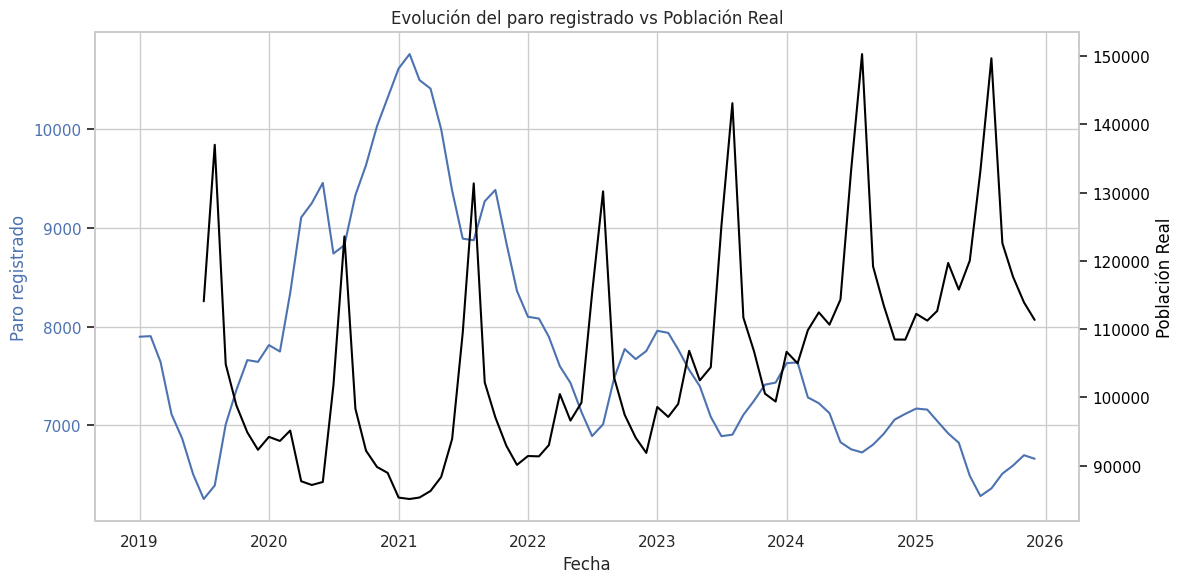

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_paro["fecha"], df_paro["total Paro Registrado"], color='b', label='Paro registrado')
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Paro registrado", color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()

ax2.plot(df_poblacion_real['fecha'], df_poblacion_real['poblacion_real'], color='black', label='Población real')
ax2.set_ylabel("Población Real", color='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.grid(True)
ax2.grid(False)

plt.title("Evolución del paro registrado vs Población Real")
fig.tight_layout()
plt.show()

Una vez visto el paro vamos a ver cómo evoluciona el número de contratos tanto indefinidos como temporales.

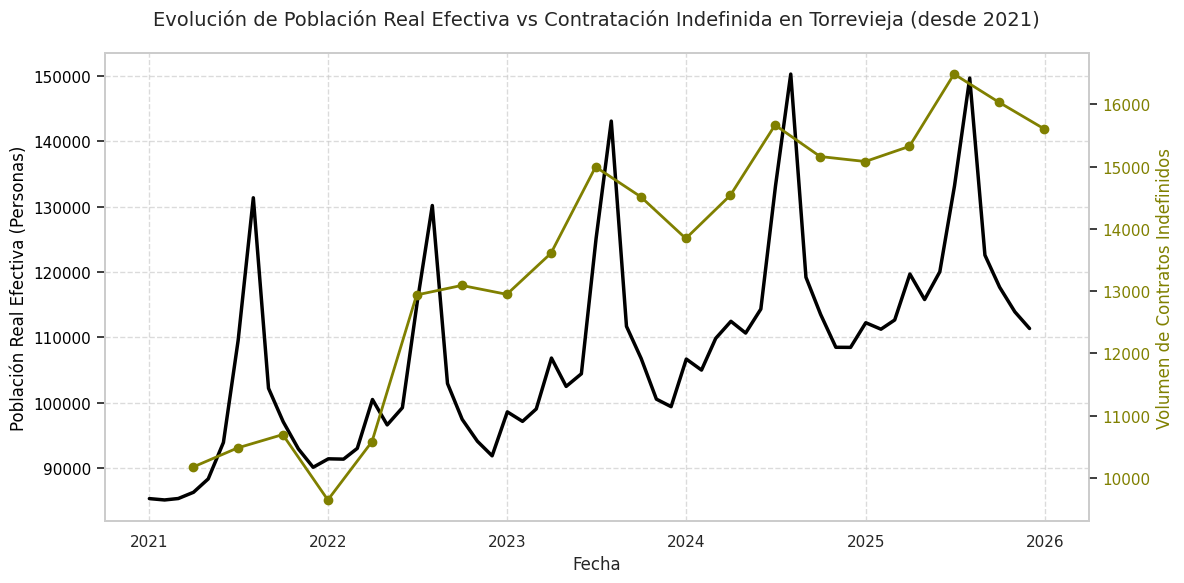

In [ ]:
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'])
df_SS_contratos['Fecha'] = pd.to_datetime(df_SS_contratos['Fecha'])

df_pob_2021 = df_poblacion_real[df_poblacion_real['fecha'] >= '2021-01-01'].sort_values('fecha')

df_indefinidos = df_SS_contratos[df_SS_contratos['Tipo de contrato'] == 'Contrato indefinido'].sort_values('Fecha')

sns.set(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

plt.title("Evolución de Población Real Efectiva vs Contratación Indefinida en Torrevieja (desde 2021)", pad=20, fontsize=14)

ax1.plot(df_pob_2021['fecha'], df_pob_2021['poblacion_real'],
         color='black', linewidth=2.5, label='Población Real Efectiva')

ax1.set_xlabel("Fecha", fontsize=12)
ax1.set_ylabel("Población Real Efectiva (Personas)", color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')


ax2 = ax1.twinx()

ax2.plot(df_indefinidos['Fecha'], df_indefinidos['Valor'],
         color='olive', linewidth=2, marker='o', markersize=6, label='Contratos Indefinidos (SS)')

ax2.set_ylabel("Volumen de Contratos Indefinidos", color='olive', fontsize=12)
ax2.tick_params(axis='y', labelcolor='olive')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(False)

plt.tight_layout()
plt.show()

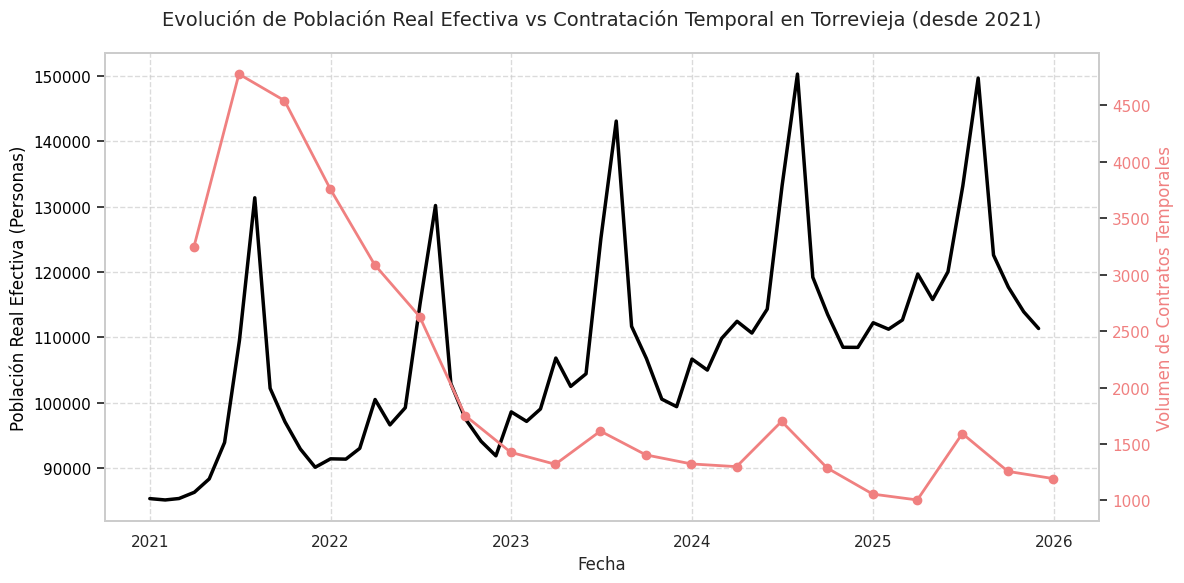

In [ ]:
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'])
df_SS_contratos['Fecha'] = pd.to_datetime(df_SS_contratos['Fecha'])

df_pob_2021 = df_poblacion_real[df_poblacion_real['fecha'] >= '2021-01-01'].sort_values('fecha')

df_temporales = df_SS_contratos[df_SS_contratos['Tipo de contrato'] == 'Contrato temporal'].sort_values('Fecha')

sns.set(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

plt.title("Evolución de Población Real Efectiva vs Contratación Temporal en Torrevieja (desde 2021)", pad=20, fontsize=14)

ax1.plot(df_pob_2021['fecha'], df_pob_2021['poblacion_real'],
         color='black', linewidth=2.5, label='Población Real Efectiva')

ax1.set_xlabel("Fecha", fontsize=12)
ax1.set_ylabel("Población Real Efectiva (Personas)", color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')


ax2 = ax1.twinx()

ax2.plot(df_temporales['Fecha'], df_temporales['Valor'],
         color='lightcoral', linewidth=2, marker='o', markersize=6, label='Contratos Temporales (SS)')

ax2.set_ylabel("Volumen de Contratos Temporales", color='lightcoral', fontsize=12)
ax2.tick_params(axis='y', labelcolor='lightcoral')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(False)

plt.tight_layout()
plt.show()

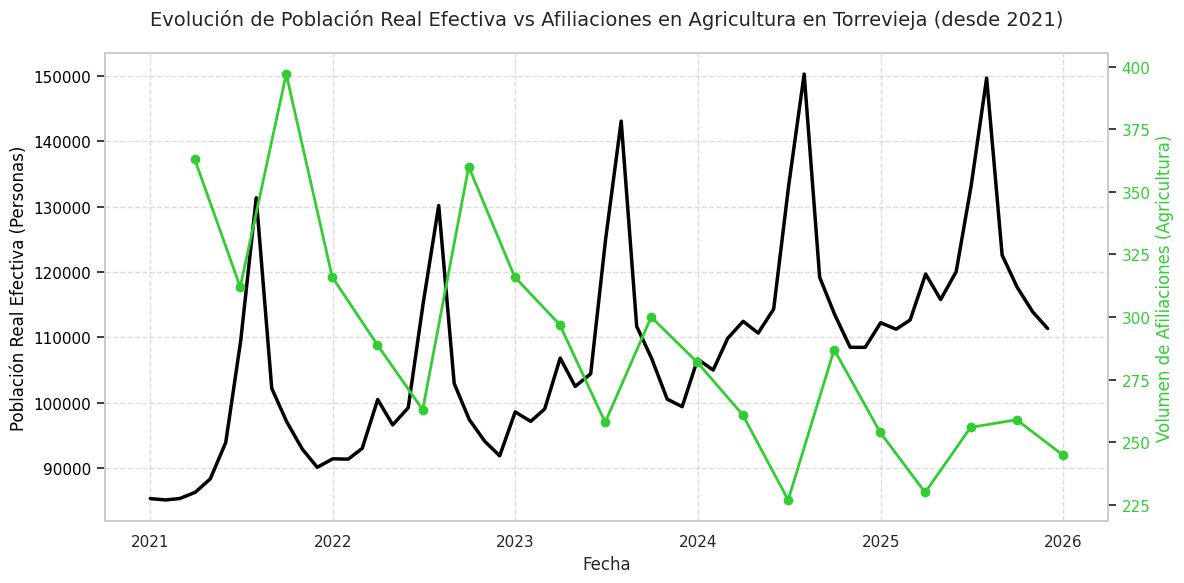

In [ ]:
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'])
df_SS_sectores['Fecha'] = pd.to_datetime(df_SS_sectores['Fecha'])

df_pob_2021 = df_poblacion_real[df_poblacion_real['fecha'] >= '2021-01-01'].sort_values('fecha')

df_agricultura = df_SS_sectores[df_SS_sectores['Sector de actividad'] == 'Agricultura'].sort_values('Fecha')

sns.set(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

plt.title("Evolución de Población Real Efectiva vs Afiliaciones en Agricultura en Torrevieja (desde 2021)", pad=20, fontsize=14)

ax1.plot(df_pob_2021['fecha'], df_pob_2021['poblacion_real'],
         color='black', linewidth=2.5, label='Población Real Efectiva')

ax1.set_xlabel("Fecha", fontsize=12)
ax1.set_ylabel("Población Real Efectiva (Personas)", color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')


ax2 = ax1.twinx()

ax2.plot(df_agricultura['Fecha'], df_agricultura['Valor'],
         color='limegreen', linewidth=2, marker='o', markersize=6, label='Afiliaciones Agricultura (SS)')

ax2.set_ylabel("Volumen de Afiliaciones (Agricultura)", color='limegreen', fontsize=12)
ax2.tick_params(axis='y', labelcolor='limegreen')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(False)

plt.tight_layout()
plt.show()

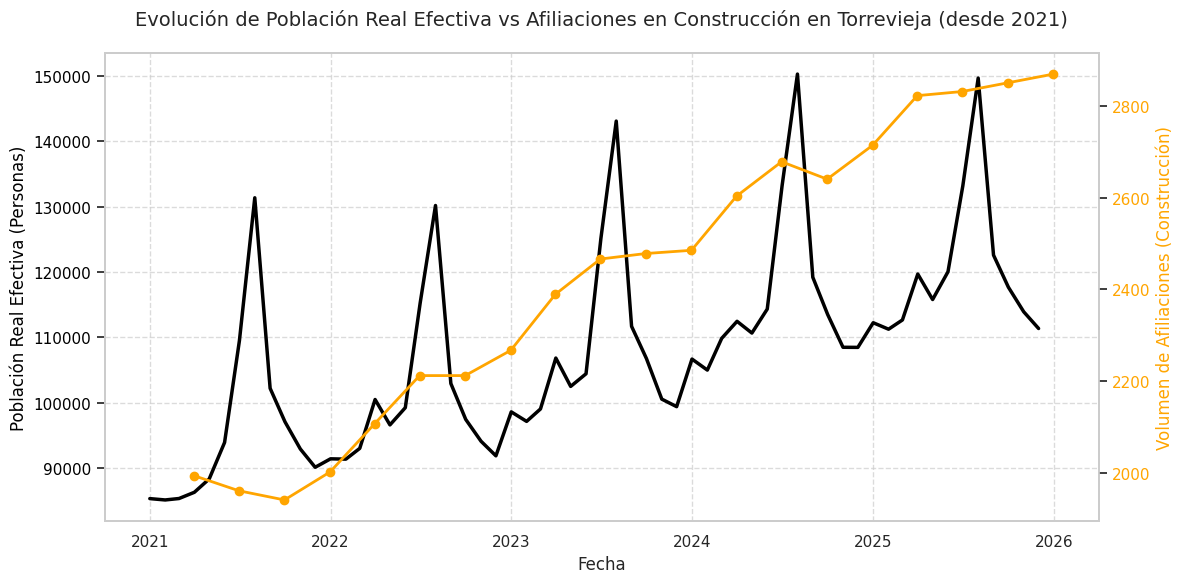

In [ ]:
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'])
df_SS_sectores['Fecha'] = pd.to_datetime(df_SS_sectores['Fecha'])

df_pob_2021 = df_poblacion_real[df_poblacion_real['fecha'] >= '2021-01-01'].sort_values('fecha')

df_construccion = df_SS_sectores[df_SS_sectores['Sector de actividad'] == 'Construcción'].sort_values('Fecha')

sns.set(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

plt.title("Evolución de Población Real Efectiva vs Afiliaciones en Construcción en Torrevieja (desde 2021)", pad=20, fontsize=14)

ax1.plot(df_pob_2021['fecha'], df_pob_2021['poblacion_real'],
         color='black', linewidth=2.5, label='Población Real Efectiva')

ax1.set_xlabel("Fecha", fontsize=12)
ax1.set_ylabel("Población Real Efectiva (Personas)", color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')


ax2 = ax1.twinx()

ax2.plot(df_construccion['Fecha'], df_construccion['Valor'],
         color='orange', linewidth=2, marker='o', markersize=6, label='Afiliaciones Construcción (SS)')

ax2.set_ylabel("Volumen de Afiliaciones (Construcción)", color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(False)

plt.tight_layout()
plt.show()

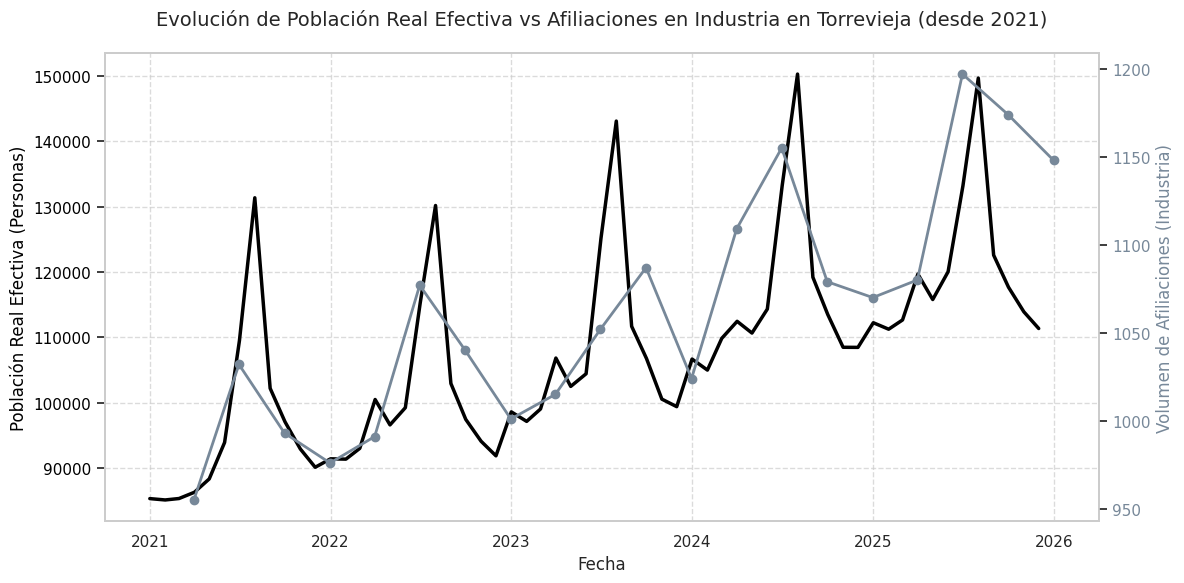

In [ ]:
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'])
df_SS_sectores['Fecha'] = pd.to_datetime(df_SS_sectores['Fecha'])

df_pob_2021 = df_poblacion_real[df_poblacion_real['fecha'] >= '2021-01-01'].sort_values('fecha')

df_industria = df_SS_sectores[df_SS_sectores['Sector de actividad'] == 'Industria'].sort_values('Fecha')

sns.set(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

plt.title("Evolución de Población Real Efectiva vs Afiliaciones en Industria en Torrevieja (desde 2021)", pad=20, fontsize=14)

ax1.plot(df_pob_2021['fecha'], df_pob_2021['poblacion_real'],
         color='black', linewidth=2.5, label='Población Real Efectiva')

ax1.set_xlabel("Fecha", fontsize=12)
ax1.set_ylabel("Población Real Efectiva (Personas)", color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')


ax2 = ax1.twinx()

ax2.plot(df_industria['Fecha'], df_industria['Valor'],
         color='lightslategray', linewidth=2, marker='o', markersize=6, label='Afiliaciones Industria (SS)')

ax2.set_ylabel("Volumen de Afiliaciones (Industria)", color='lightslategray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='lightslategray')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(False)

plt.tight_layout()
plt.show()

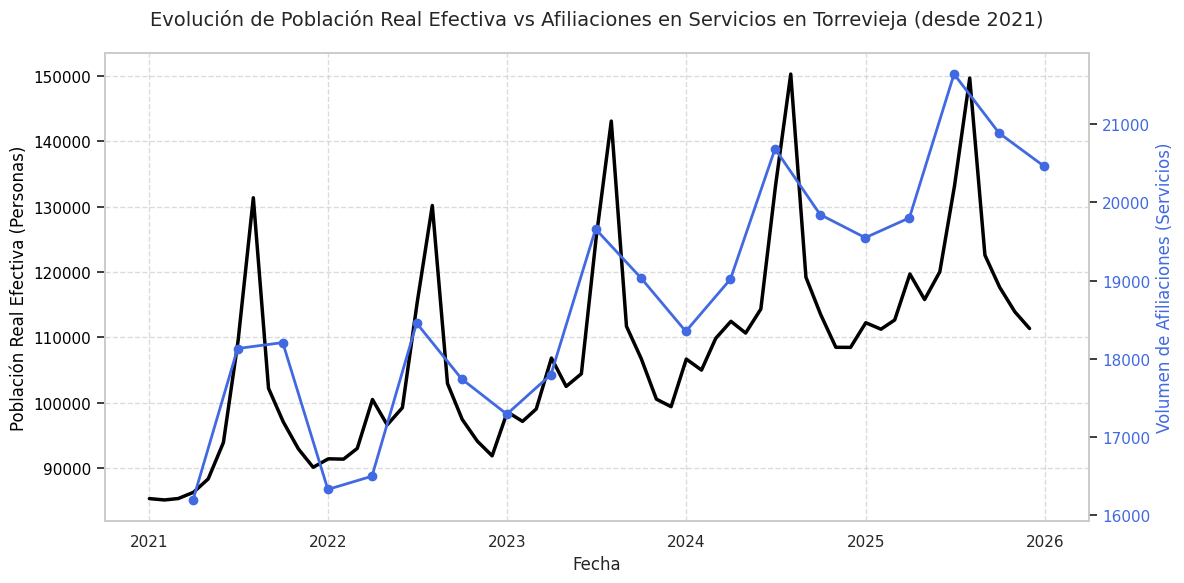

In [ ]:
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'])
df_SS_sectores['Fecha'] = pd.to_datetime(df_SS_sectores['Fecha'])

df_pob_2021 = df_poblacion_real[df_poblacion_real['fecha'] >= '2021-01-01'].sort_values('fecha')

df_servicios = df_SS_sectores[df_SS_sectores['Sector de actividad'] == 'Servicios'].sort_values('Fecha')

sns.set(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

plt.title("Evolución de Población Real Efectiva vs Afiliaciones en Servicios en Torrevieja (desde 2021)", pad=20, fontsize=14)

ax1.plot(df_pob_2021['fecha'], df_pob_2021['poblacion_real'],
         color='black', linewidth=2.5, label='Población Real Efectiva')

ax1.set_xlabel("Fecha", fontsize=12)
ax1.set_ylabel("Población Real Efectiva (Personas)", color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')


ax2 = ax1.twinx()

ax2.plot(df_servicios['Fecha'], df_servicios['Valor'],
         color='royalblue', linewidth=2, marker='o', markersize=6, label='Afiliaciones Servicios (SS)')

ax2.set_ylabel("Volumen de Afiliaciones (Servicios)", color='royalblue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='royalblue')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(False)

plt.tight_layout()
plt.show()

En esta parte vamos a analizar el número de búsquedas de distintas palabras relacionadas con torrevieja, en Google Trends. Primero procesamos:

In [ ]:
'''
import pandas as pd
from google.colab import files
import io

# Subir múltiples archivos
uploaded = files.upload()

df_final = None

for filename in uploaded.keys():
    # Leer CSV separado por comas
    df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=",")

    # Convertir la columna Time a datetime
    df['Time'] = pd.to_datetime(df['Time'])

    # Inicializar o hacer merge
    if df_final is None:
        df_final = df
    else:
        df_final = pd.merge(df_final, df, on='Time', how='outer')

# Ordenar por fecha
df_final = df_final.sort_values('Time').reset_index(drop=True)

# Cambiamos nombres de las columnas
df_final = df_final.rename(columns={
    'Time': 'fecha',
    'apartamentos torrevieja': 'apartamentos_torrevieja',
    'playa torrevieja': 'playa_torrevieja',
    'restaurantes torrevieja': 'restaurantes_torrevieja',
    'torrevieja_x': 'torrevieja_España',
    'torrevieja_y': 'torrevieja_Mundo',
    'tren torrevieja': 'tren_torrevieja'
})

# Mostrar resultado
df_final.head()

df_final.to_csv('df_final.csv', index=False)

from google.colab import files
files.download('df_final.csv')
'''

In [ ]:
df_GoogleTrends.head()

,fecha,apartamentos_torrevieja,playa_torrevieja,restaurantes_torrevieja,torrevieja_España,torrevieja_Mundo,tren_torrevieja
0,2004-01-01,0,0,0,17,43,0
1,2004-02-01,0,0,0,19,42,0
2,2004-03-01,71,0,0,21,45,0
3,2004-04-01,0,0,0,22,45,0
4,2004-05-01,53,0,0,21,46,0


Vamos a tratar ahora el dataframe de segundas residencias:

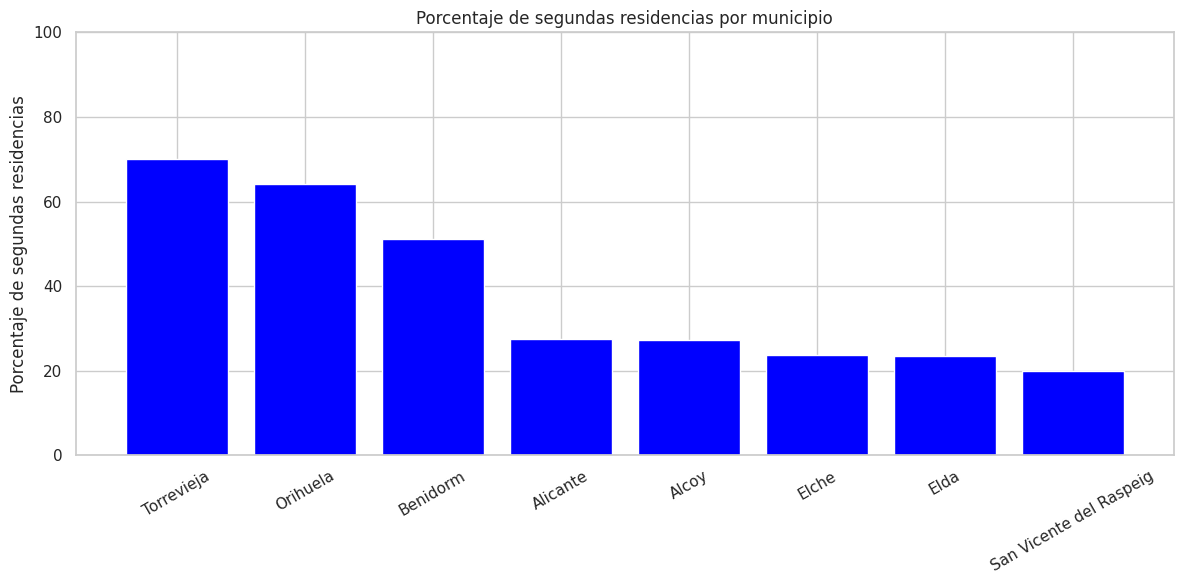

In [ ]:
# Cambiamos el nombre a las columnas:

df_SegundasResidencias['Municipios (con más de 50.000 habitantes) y capitales de provincia'] = df_SegundasResidencias['Municipios (con más de 50.000 habitantes) y capitales de provincia'].replace({
    '03009 Alcoy/Alcoi': 'Alcoy',
    '03014 Alicante/Alacant': 'Alicante',
    '03031 Benidorm': 'Benidorm',
    '03065 Elche/Elx': 'Elche',
    '03066 Elda': 'Elda',
    '03099 Orihuela': 'Orihuela',
    '03122 San Vicente del Raspeig/Sant Vicent del Raspeig': 'San Vicente del Raspeig',
    '03133 Torrevieja': 'Torrevieja',

})

# Pivotar el DataFrame usando los valores correctos
df_pivot = df_SegundasResidencias.pivot(
    index='Municipios (con más de 50.000 habitantes) y capitales de provincia',
    columns='Tipo de vivienda (principal o no)',
    values='Total'
)

# Calcular el porcentaje de viviendas no principales
df_pivot['Porcentaje_no_principal'] = (
    df_pivot['Vivienda no principal'] /
    (df_pivot['Vivienda principal'] + df_pivot['Vivienda no principal']) * 100
)

# Ordenar de mayor a menor
df_pivot = df_pivot.sort_values('Porcentaje_no_principal', ascending=False)

# Gráfico de barras
plt.figure(figsize=(12,6))
plt.bar(df_pivot.index, df_pivot['Porcentaje_no_principal'], color='blue')
plt.xticks(rotation=30)
plt.ylabel('Porcentaje de segundas residencias')
plt.title('Porcentaje de segundas residencias por municipio')
plt.ylim(0,100)
plt.tight_layout()
plt.show()

In [ ]:
df_pivot.head()

Tipo de vivienda (principal o no),Vivienda no principal,Vivienda principal,Porcentaje_no_principal
Municipios (con más de 50.000 habitantes) y capitales de provincia,,,
Torrevieja,85.907,36.829,69.993319
Orihuela,56.703,31.805,64.065395
Benidorm,30.929,29.550,51.140065
Alicante,51.794,135.864,27.600209
Alcoy,9.261,24.615,27.337938


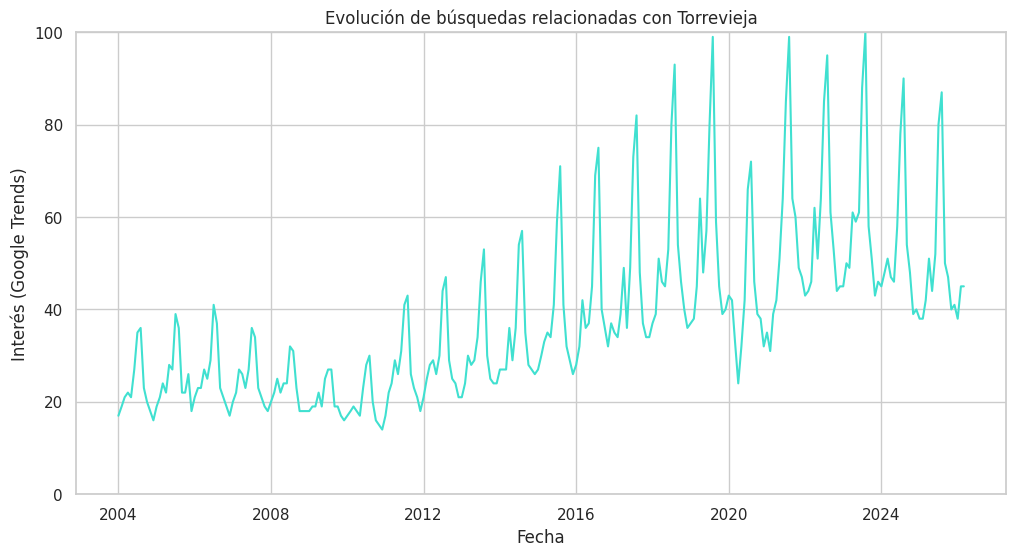

In [ ]:
import matplotlib.pyplot as plt

# Asegurar que la fecha es datetime
df_GoogleTrends['fecha'] = pd.to_datetime(df_GoogleTrends['fecha'])

# Crear gráfico
plt.figure(figsize=(12,6))
plt.plot(df_GoogleTrends['fecha'], df_GoogleTrends['torrevieja_España'], color="turquoise")

# Personalización
plt.ylim(0, 100)
plt.xlabel('Fecha')
plt.ylabel('Interés (Google Trends)')
plt.title('Evolución de búsquedas relacionadas con Torrevieja')
#plt.legend(title='Búsquedas')
plt.grid(True)

plt.show()

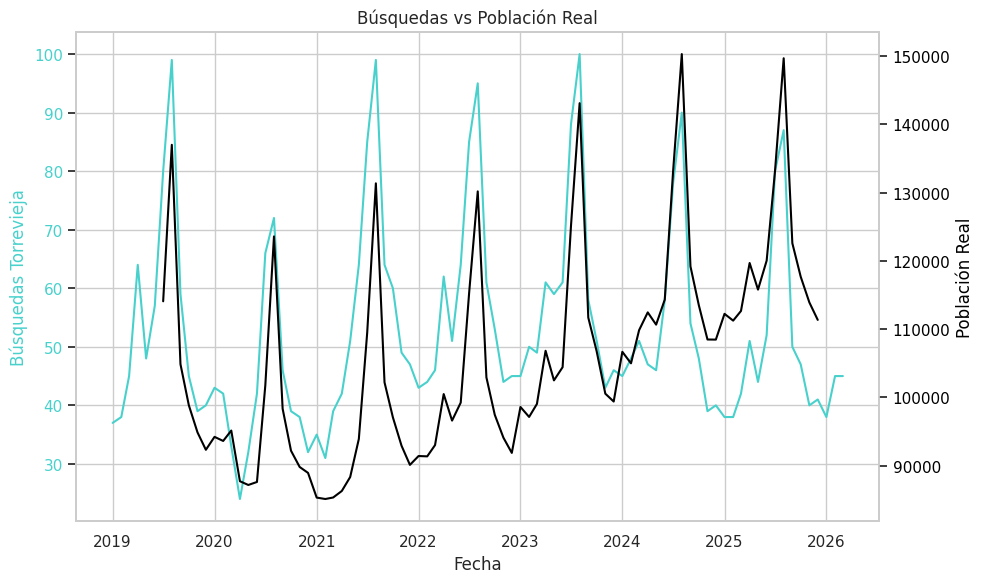

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Vamos a filtrar solo a partir de 2019.
df_temp = df_GoogleTrends[df_GoogleTrends['fecha'] >= '2019-01-01']

ax1.plot(df_temp["fecha"], df_temp["torrevieja_España"], color='mediumturquoise', label='Búsquedas en Google')
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Búsquedas Torrevieja", color='mediumturquoise')
ax1.tick_params(axis='y', labelcolor='mediumturquoise')

ax2 = ax1.twinx()

ax2.plot(df_poblacion_real['fecha'], df_poblacion_real['poblacion_real'], color='black', label='Población real')
ax2.set_ylabel("Población Real", color='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.grid(True)
ax2.grid(False)

plt.title("Búsquedas vs Población Real")
fig.tight_layout()
plt.show()

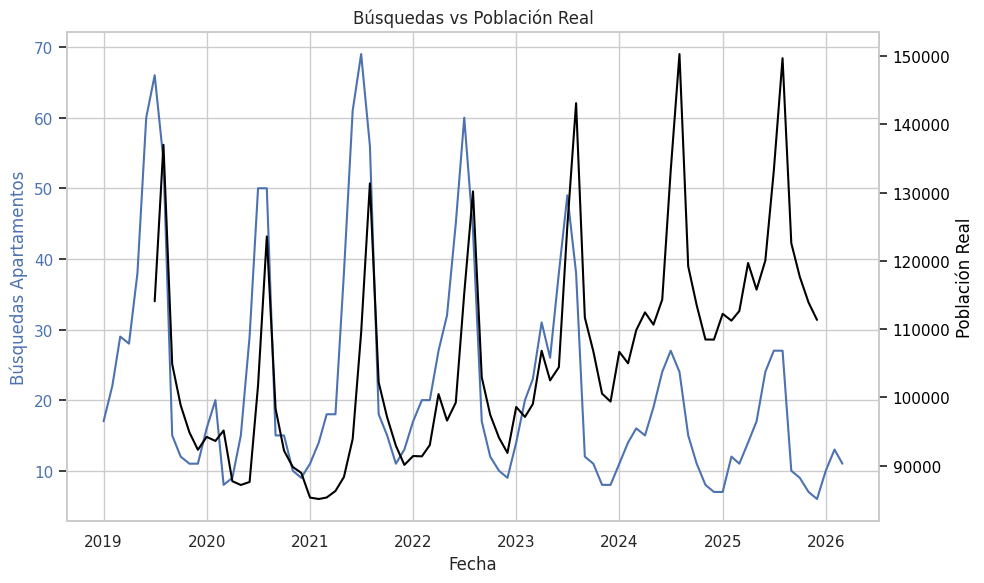

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Vamos a filtrar solo a partir de 2019.
df_temp = df_GoogleTrends[df_GoogleTrends['fecha'] >= '2019-01-01']

ax1.plot(df_temp["fecha"], df_temp["apartamentos_torrevieja"], color='b', label='Búsquedas en Google')
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Búsquedas Apartamentos", color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()

ax2.plot(df_poblacion_real['fecha'], df_poblacion_real['poblacion_real'], color='black', label='Población real')
ax2.set_ylabel("Población Real", color='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.grid(True)
ax2.grid(False)

plt.title("Búsquedas vs Población Real")
fig.tight_layout()
plt.show()

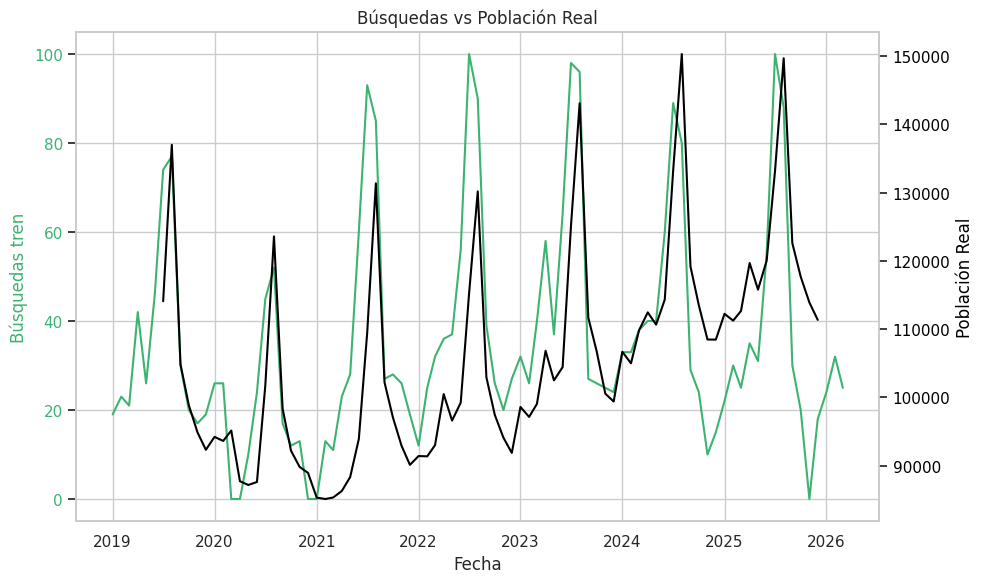

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Vamos a filtrar solo a partir de 2019.
df_temp = df_GoogleTrends[df_GoogleTrends['fecha'] >= '2019-01-01']

ax1.plot(df_temp["fecha"], df_temp["tren_torrevieja"], color='mediumseagreen', label='Búsquedas en Google')
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Búsquedas tren", color='mediumseagreen')
ax1.tick_params(axis='y', labelcolor='mediumseagreen')

ax2 = ax1.twinx()

ax2.plot(df_poblacion_real['fecha'], df_poblacion_real['poblacion_real'], color='black', label='Población real')
ax2.set_ylabel("Población Real", color='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.grid(True)
ax2.grid(False)

plt.title("Búsquedas vs Población Real")
fig.tight_layout()
plt.show()

## Reto 3. Viviendas de Uso Turístico (VUT)

### Carga y preparación de nuevos conjuntos de datos

In [ ]:
# --- 11. VUT_GVA --- (Para el número de VUT)
nombre_vut_gva = 'VUT_GVA.csv'
if nombre_vut_gva in archivos_subidos:
    df_vut_gva = pd.read_csv(io.BytesIO(archivos_subidos[nombre_vut_gva]), sep=";", encoding="utf-8-sig")
    print(f"{nombre_vut_gva} cargado correctamente.")
else:
    print(f"No se encontró {nombre_vut_gva}")

# --- 12. VUT_INE --- (Para la evolución de las VUT)
nombre_vut_ine = 'VUT_INE.csv'
if nombre_vut_ine in archivos_subidos:
    df_vut_ine = pd.read_csv(io.BytesIO(archivos_subidos[nombre_vut_ine]), sep=",", encoding="utf-8-sig")
    print(f"{nombre_vut_ine} cargado correctamente.")
else:
    print(f"No se encontró {nombre_vut_ine}")

11. Por favor, selecciona tu archivo de VUT_GVA (.csv):


Saving VUT_GVA.csv to VUT_GVA.csv
12. Por favor, selecciona tu archivo de VUT_INE (.csv):


Saving VUT_INE.csv to VUT_INE.csv


In [ ]:
# --- 13. ALOJAMIENTO REGLADO (Hoteles, Hostales y Pensiones) ---

# Hoteles
nombre_hoteles = 'lista_hoteles.csv'
if nombre_hoteles in archivos_subidos:
    lista_hoteles = pd.read_csv(io.BytesIO(archivos_subidos[nombre_hoteles]), sep=";", encoding="latin1")
    print(f"{nombre_hoteles} cargado correctamente.")
else:
    print(f"No se encontró {nombre_hoteles}")

# Hostales
nombre_hostales = 'lista_hostales.csv'
if nombre_hostales in archivos_subidos:
    lista_hostales = pd.read_csv(io.BytesIO(archivos_subidos[nombre_hostales]), sep=";", encoding="latin1")
    print(f"{nombre_hostales} cargado correctamente.")
else:
    print(f"No se encontró {nombre_hostales}")

# Pensiones
nombre_pensiones = 'lista_pensiones.csv'
if nombre_pensiones in archivos_subidos:
    lista_pensiones = pd.read_csv(io.BytesIO(archivos_subidos[nombre_pensiones]), sep=";", encoding="latin1")
    print(f"{nombre_pensiones} cargado correctamente.")
else:
    print(f"No se encontró {nombre_pensiones}")

13. Por favor, selecciona a la vez las 3 listas de alojamiento (.csv):


Saving lista_hostales.csv to lista_hostales.csv
Saving lista_hoteles.csv to lista_hoteles.csv
Saving lista_pensiones.csv to lista_pensiones.csv

¡Los tres conjuntos de datos de alojamiento reglado se han cargado con éxito!


In [ ]:
df_vut_gva.head()

,Nº de inscripción,Nombre,Provincia,Municipio,CP,Dirección,Sitio web,Fecha alta,Referencia catastral,Código registral único,Rural,Superficie,Plazas totales,Estudio,Habitaciones dobles,Plazas dobles,Habitaciones individuales,Plazas individuales,Total dormitorios
0,CV-VUT0518656-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3188,"AV ALEMANIA-MATA, 100, Es:1 Pl:00 Pt:F",NaN,06/10/2025,6012404YH0161S0002HL,NaN,N,"62,00",4,N,2.0,4,0.0,0,2.0
1,CV-VUT0518659-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3182,"CL LOMA LA, 90, Es:1 Pl:02 Pt:0C",NaN,06/10/2025,5065603YH0056N0011FQ,NaN,N,"65,00",4,N,2.0,4,0.0,0,2.0
2,CV-VUT0518661-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3180,"CL RAMON GALLUD, 164, Es:1 Pl:03 Pt:A",NaN,07/10/2025,4560401YH0046S0025DH,NaN,N,"78,00",4,N,2.0,4,0.0,0,2.0
3,CV-VUT0516840-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3180,"UR HONDO EL, 8M, Es:1 Pl:00 Pt:43",NaN,20/05/2025,2183401YH0028S0043QI,NaN,N,"72,00",6,N,2.0,4,2.0,2,4.0
4,CV-VUT0516855-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3180,"AV HABANERAS DE LAS, 88, Es:1 Pl:05 Pt:D",NaN,02/06/2025,5164704YH0056S0030RX,NaN,N,"117,00",4,N,2.0,4,0.0,0,2.0


In [ ]:
'''

# Preparamos df_vut_ine:

# Pasamos la columna Periodo a formato fecha:

#df_vut_ine['Periodo'] = pd.to_datetime(df_vut_ine['Periodo'].str.replace('M', '-', regex=False) + '-01', format='%Y-%m-%d')

df_vut_ine['Total'] = pd.to_numeric(df_vut_ine['Total'].str.replace('.', '', regex=False), errors='coerce')

df_vut_ine.to_csv('df_vut_ine.csv', index=False)

files.download('df_vut_ine.csv')

'''

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Análisis

In [ ]:
df_temp = df_vut_gva

print('Primero tenemos estas vuts:', len(df_temp))
print('Si nos fijamos en Nº de inscripción, tenemos estos duplicados:', df_temp.duplicated(subset=['Nº de inscripción']).sum())
print('Si nos fijamos en Referencia catastral, tenemos estos duplicados:', df_temp.duplicated(subset=['Referencia catastral']).sum())
print('Nos deberían de quedar:', len(df_temp) - df_temp.duplicated(subset=['Referencia catastral']).sum())
df_temp = df_temp.drop_duplicates(subset=['Referencia catastral'], keep='first')
print('Nos quedan:', len(df_temp))
print('Con CP y Dirección tenemos estos duplicados:', df_temp.duplicated(subset=['CP', 'Dirección']).sum())
print('Nos deberían de quedar:', len(df_temp) - df_temp.duplicated(subset=['CP', 'Dirección']).sum())
df_temp = df_temp.drop_duplicates(subset=['CP', 'Dirección'], keep='first')
print('Nos quedan:', len(df_temp))

Primero tenemos estas vuts: 9908
Si nos fijamos en Nº de inscripción, tenemos estos duplicados: 0
Si nos fijamos en Referencia catastral, tenemos estos duplicados: 48
Nos deberían de quedar: 9860
Nos quedan: 9860
Con CP y Dirección tenemos estos duplicados: 7
Nos deberían de quedar: 9853
Nos quedan: 9853


Como no cuadraban los resultados actuales de los dos dataset se intentó corregir los duplicados para ver si el problema era ese, sin éxito.

Veamos por CP, para ver dónde se concentran:

In [ ]:
df_vut_gva['CP'].value_counts()

,count
CP,
3180,5866
3185,962
3183,943
3182,822
3188,551
3181,321
3184,303
3186,140


In [ ]:
962+943+822+551+321+303+140

4042

Se observa que la mayoría de viviendas tiene el CP de 3180, pero este no existe acutalmente, además, si sumamos el resto obtenemos un valor parecido al del otro dataset. Finalmente se toma la decisión más adelante de eliminar las viviendas con código postal 3180.

Veamos ahora la evolución del número de VUT en Torrevieja, desde 2020, cambiamos la columna Periodo a formato fecha:

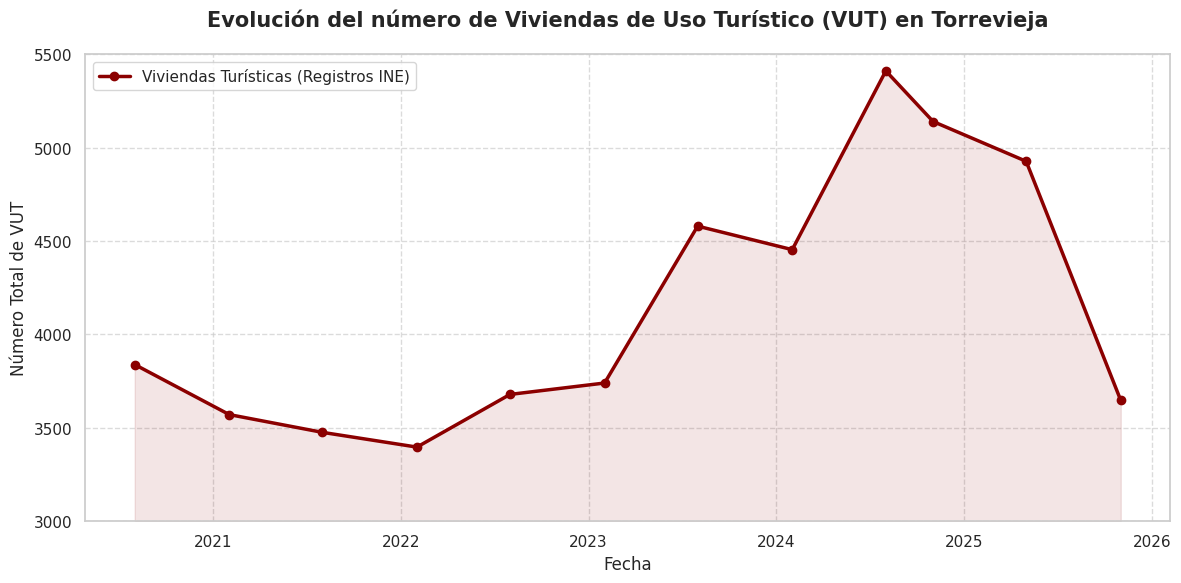

In [ ]:
# Asegurar que la fecha es datetime
df_vut_ine['Periodo'] = pd.to_datetime(df_vut_ine['Periodo'])

# Nos quedamos solo con las viviendas turísticas y aseguramos el orden cronológico
df_temp = df_vut_ine[df_vut_ine['Viviendas y plazas'] == 'Viviendas turísticas'].sort_values('Periodo')


sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))
plt.title('Evolución del número de Viviendas de Uso Turístico (VUT) en Torrevieja',
          pad=20, fontsize=15, fontweight='bold')

ax.plot(df_temp['Periodo'], df_temp['Total'], color='darkred', linewidth=2.5, marker='o', markersize=6, label='Viviendas Turísticas (Registros INE)')

ax.fill_between(df_temp['Periodo'], df_temp['Total'], 3000, color='darkred', alpha=0.1)

ax.set_ylim(3000, 5500)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Número Total de VUT', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
df_temp

,Total Nacional,Comunidades y Ciudades Autónomas,Provincias,Municipios,Viviendas y plazas,Periodo,Total
11,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2020-08-01,3839.0
10,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2021-02-01,3571.0
9,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2021-08-01,3476.0
8,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2022-02-01,3397.0
7,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2022-08-01,3679.0
6,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2023-02-01,3740.0
5,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2023-08-01,4580.0
4,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2024-02-01,4454.0
3,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2024-08-01,5411.0
2,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2024-11-01,5140.0


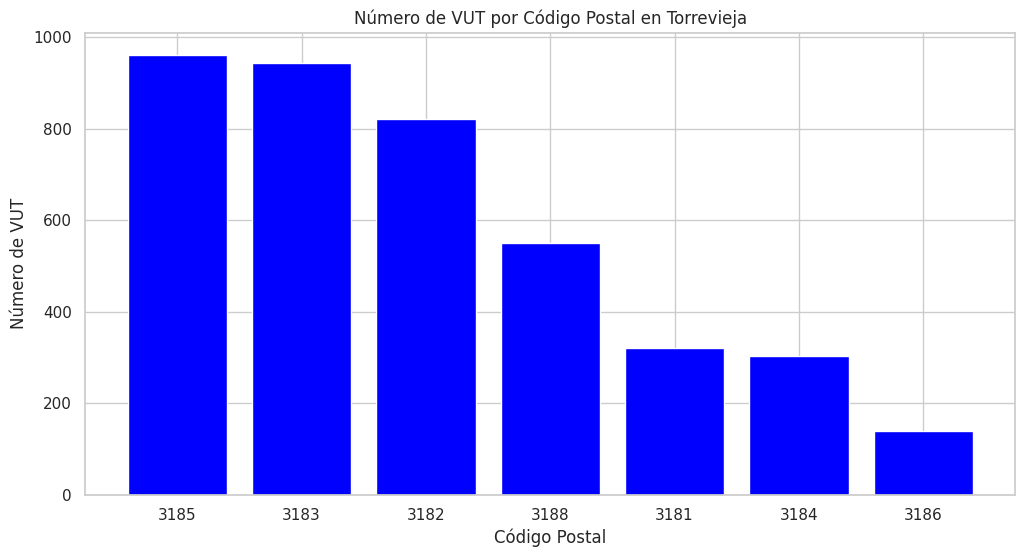

In [ ]:
# Eliminamos el CP == 3180.
df_temp = df_vut_gva[df_vut_gva['CP'] != 3180]

# Contar cuántas VUT hay por código postal
vut_por_cp = df_temp.groupby('CP').size().reset_index(name='num_vut')

# Ordenar por número de VUT de mayor a menor
vut_por_cp = vut_por_cp.sort_values('num_vut', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(vut_por_cp['CP'].astype(str), vut_por_cp['num_vut'], color='blue')
plt.xlabel('Código Postal')
plt.ylabel('Número de VUT')
plt.title('Número de VUT por Código Postal en Torrevieja')
plt.xticks(rotation=0)
plt.show()

Veamos para cuántas personas son capaces de proporcionar alojamiento los hoteles, hostales y pensiones de Torrevieja.

In [ ]:
lista_hoteles['Plazas'].sum() + lista_hostales['Plazas'].sum() + lista_pensiones['Plazas'].sum()

np.int64(1969)

Nos interesa ahora estudiar también el número de plazas que poseen las VUT. De esta manera podemos determinar el número de personas a las que pueden dar alojamiento y comparar con el sector hotelero.

In [ ]:
# Asegurarnos de que la columna es estrictamente numérica (convierte errores en nulos)
df_vut_gva['Plazas totales'] = pd.to_numeric(df_vut_gva['Plazas totales'], errors='coerce')

# Sumar todas las plazas
total_plazas_vut = df_vut_gva['Plazas totales'].sum()

# Mostrar el resultado formateado (con separador de miles)
print(f"La capacidad total de las Viviendas de Uso Turístico (VUT) es de: {total_plazas_vut:,.0f} plazas.")

La capacidad total de las Viviendas de Uso Turístico (VUT) es de: 39,117 plazas.


## Reto 4. Sostenibilidad ambiental y cohesión social

### Carga y preparación de nuevos conjuntos de datos

In [ ]:
# --- 14. Laguna la mata ---
nombre_LagunaTorrevieja = 'df_LagunaTorrevieja.csv'
if nombre_LagunaTorrevieja in archivos_subidos:
    df_LagunaTorrevieja = pd.read_csv(io.BytesIO(archivos_subidos[nombre_LagunaTorrevieja]), sep=",", encoding="utf-8-sig")
    print(f"{nombre_LagunaTorrevieja} cargado correctamente.")
else:
    print(f"No se encontró {nombre_LagunaTorrevieja}")

14. Por favor, selecciona tu archivo de LagunaTorrevieja (.csv):


Saving df_LagunaTorrevieja.csv to df_LagunaTorrevieja.csv


In [ ]:
'''

df_LagunaTorrevieja1 = df_LagunaTorrevieja1[["FECHA", "FÓSFORO_TOTAL", "NITRATOS", "CLOROFILA_A", "OXÍGENO_DISUELTO", "CONDUCTIVIDAD"]]

df_LagunaTorrevieja1.count()

df_LagunaTorrevieja1.to_csv('df_LagunaTorrevieja1.csv', index=False)

files.download('df_LagunaTorrevieja1.csv')

'''

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tratamiento de datos

In [ ]:
df_LagunaTorrevieja.head()

,FECHA,FÓSFORO_TOTAL,NITRATOS,CLOROFILA_A,OXÍGENO_DISUELTO,CONDUCTIVIDAD
0,2019-01-22,0.7,9.1,1.19,5.43,115000.0
1,2019-11-06,"<,5",11.6,30,4.03,123400.0
2,2023-02-01,2.27,"<,5",0.75,NaN,196000.0
3,2023-11-07,NaN,"<1,5",4.6,6.03,182400.0
4,2024-07-02,"<,5","<1,5",3.5,12.00,148700.0


In [ ]:
# Primero la columna de FÓSFORO_TOTAL:

df_LagunaTorrevieja['FÓSFORO_TOTAL'] = df_LagunaTorrevieja['FÓSFORO_TOTAL'].replace('<,5', 0.25)
df_LagunaTorrevieja['FÓSFORO_TOTAL'] = pd.to_numeric(df_LagunaTorrevieja['FÓSFORO_TOTAL'], errors='coerce')

# Ahora la columna NITRATOS:

df_LagunaTorrevieja['NITRATOS'] = df_LagunaTorrevieja['NITRATOS'].replace('<,5', 0.25)
df_LagunaTorrevieja['NITRATOS'] = df_LagunaTorrevieja['NITRATOS'].replace('<1,5', 0.75)
df_LagunaTorrevieja['NITRATOS'] = df_LagunaTorrevieja['NITRATOS'].replace('<15', 7.5)
df_LagunaTorrevieja['NITRATOS'] = df_LagunaTorrevieja['NITRATOS'].replace('<30', 15)
df_LagunaTorrevieja['NITRATOS'] = pd.to_numeric(df_LagunaTorrevieja['NITRATOS'], errors='coerce')

# Seguimos con CLOROFILA_A:

df_LagunaTorrevieja['CLOROFILA_A'] = df_LagunaTorrevieja['CLOROFILA_A'].replace('<,1', 0.05)
df_LagunaTorrevieja['CLOROFILA_A'] = pd.to_numeric(df_LagunaTorrevieja['CLOROFILA_A'], errors='coerce')

# Las columnas de OXÍGENO_DISUELTO y CONDUCTIVIDAD ya están como queremos.

# Nos aseguramos de que la columna fecha esta en la clase fecha y ordenamos cronológicamente:

df_LagunaTorrevieja['FECHA'] = pd.to_datetime(df_LagunaTorrevieja['FECHA'], errors='coerce')
df_LagunaTorrevieja = df_LagunaTorrevieja.sort_values(by='FECHA')

df_LagunaTorrevieja.head()

,FECHA,FÓSFORO_TOTAL,NITRATOS,CLOROFILA_A,OXÍGENO_DISUELTO,CONDUCTIVIDAD
0,2019-01-22,0.70,9.1,1.19,5.43,115000.0
7,2019-03-06,0.25,9.7,1.19,1.48,NaN
35,2019-05-22,0.25,7.1,2.22,9.12,112100.0
22,2019-07-04,0.25,9.8,8.67,6.15,128700.0
30,2019-09-04,0.25,10.3,14.45,8.78,142400.0


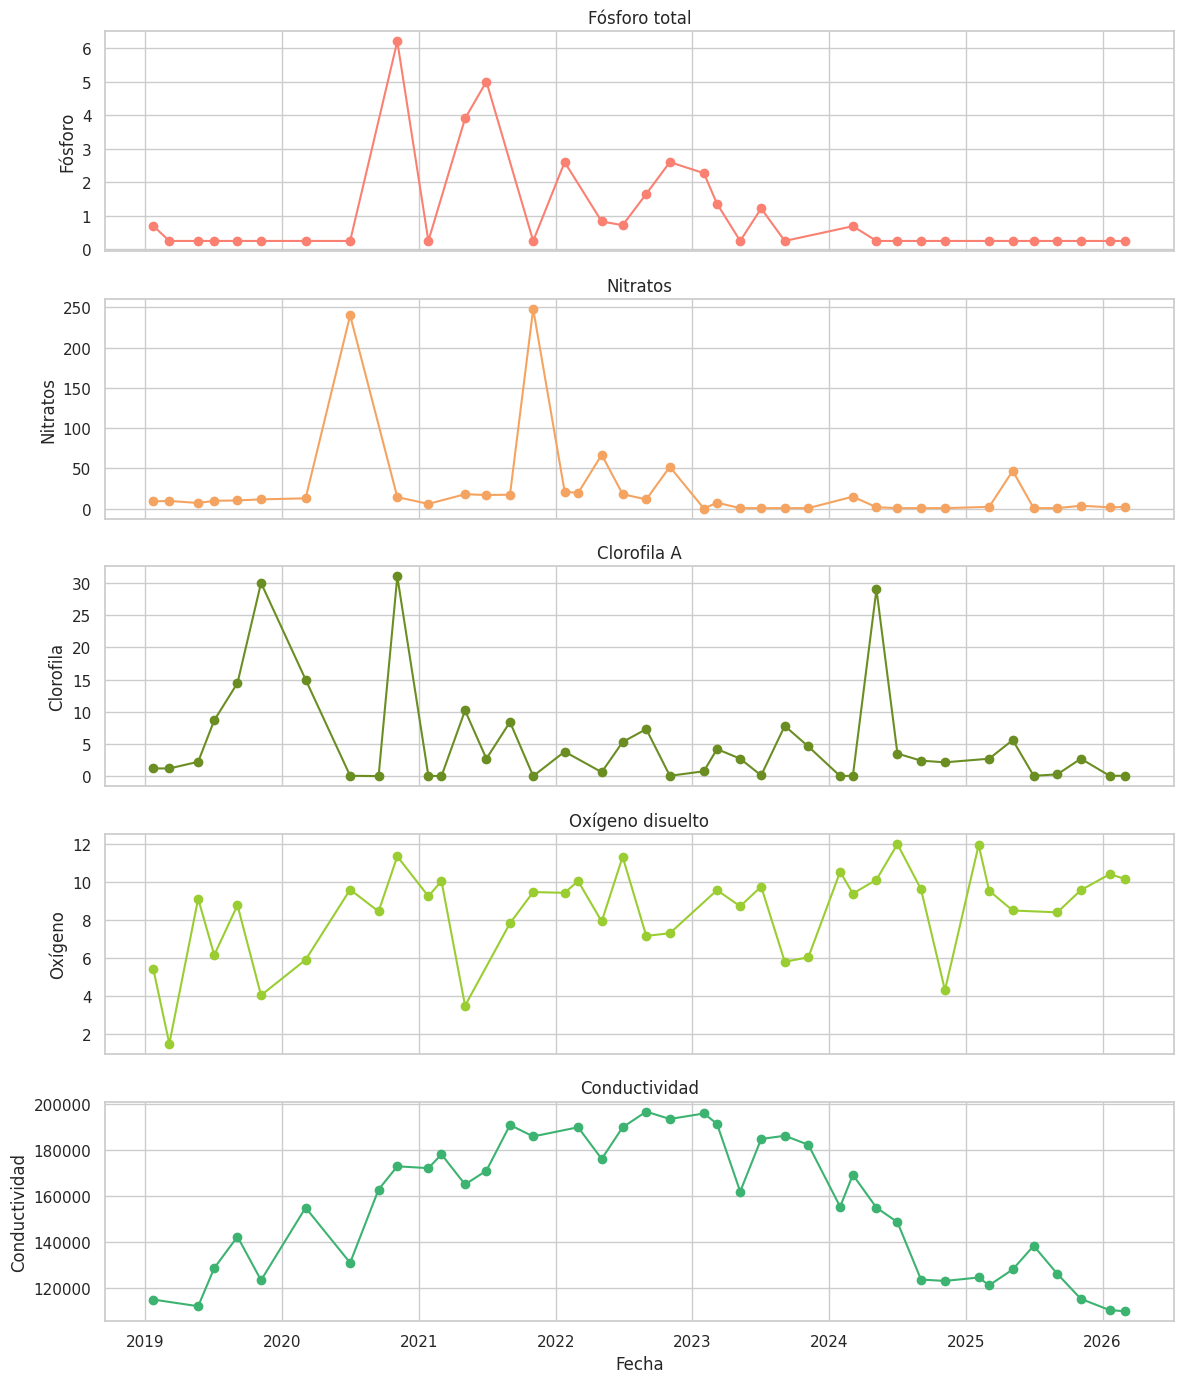

In [ ]:
# Filtrar fechas válidas
df_temp = df_LagunaTorrevieja.dropna(subset=['FECHA'])

fig, axs = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

# FÓSFORO
df_p = df_temp.dropna(subset=['FÓSFORO_TOTAL'])
axs[0].plot(df_p['FECHA'], df_p['FÓSFORO_TOTAL'], marker='o', linestyle='-', color='salmon')
axs[0].set_ylabel("Fósforo")
axs[0].set_title("Fósforo total")

# NITRATOS
df_n = df_temp.dropna(subset=['NITRATOS'])
axs[1].plot(df_n['FECHA'], df_n['NITRATOS'], marker='o', linestyle='-', color='sandybrown')
axs[1].set_ylabel("Nitratos")
axs[1].set_title("Nitratos")

# CLOROFILA
df_c = df_temp.dropna(subset=['CLOROFILA_A'])
axs[2].plot(df_c['FECHA'], df_c['CLOROFILA_A'], marker='o', linestyle='-', color='olivedrab')
axs[2].set_ylabel("Clorofila")
axs[2].set_title("Clorofila A")

# OXÍGENO
df_o = df_temp.dropna(subset=['OXÍGENO_DISUELTO'])
axs[3].plot(df_o['FECHA'], df_o['OXÍGENO_DISUELTO'], marker='o', linestyle='-', color='yellowgreen')
axs[3].set_ylabel("Oxígeno")
axs[3].set_title("Oxígeno disuelto")

# CONDUCTIVIDAD
df_cond = df_temp.dropna(subset=['CONDUCTIVIDAD'])
axs[4].plot(df_cond['FECHA'], df_cond['CONDUCTIVIDAD'], marker='o', linestyle='-', color='mediumseagreen')
axs[4].set_ylabel("Conductividad")
axs[4].set_title("Conductividad")

for ax in axs:
    ax.grid(True)

axs[-1].set_xlabel("Fecha")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Carga y limpieza de los datos de criminalidad:

In [ ]:
'''
# Subir los archivos
print("Por favor, selecciona y sube todos tus archivos CSV a la vez:")
uploaded = files.upload()

# Definimos el diccionario para estandarizar los delitos antiguos al formato nuevo.
mapeo_delitos = {
    "1.-Homicidios dolosos y asesinatos consumados": "1. Homicidios dolosos y asesinatos consumados",
    "2.-Homicidios dolosos y asesinatos en grado tentativa": "2. Homicidios dolosos y asesinatos en grado tentativa",
    "3.-Delitos graves y menos graves de lesiones y riña tumultuaria": "3. Delitos graves y menos graves de lesiones y riña tumultuaria",
    "4.-Secuestro": "4. Secuestro",
    "5.-Delitos contra la libertad e indemnidad sexual": "5. Delitos contra la libertad sexual",
    "5.1.-Agresión sexual con penetración": "5.1.-Agresión sexual con penetración",
    "5.2.-Resto de delitos contra la libertad e indemnidad sexual": "5.2.-Resto de delitos contra la libertad sexual",
    "6.-Robos con violencia e intimidación": "6. Robos con violencia e intimidación",
    "7.- Robos con fuerza en domicilios, establecimientos y otras instalaciones": "7. Robos con fuerza en domicilios, establecimientos y otras instalaciones",
    "7.1.-Robos con fuerza en domicilios": "7.1.-Robos con fuerza en domicilios",
    "8.-Hurtos": "8. Hurtos",
    "9.-Sustracciones de vehículos": "9. Sustracciones de vehículos",
    "10.-Tráfico de drogas": "10. Tráfico de drogas",
    "Resto de infracciones penales": "11. Resto de criminalidad convencional",
    "TOTAL INFRACCIONES PENALES": "III. TOTAL INFRACCIONES PENALES"
}

lista_dfs = []

# Procesar los archivos subidos
for nombre_archivo in uploaded.keys():
    # Extraer el Año y el Trimestre a partir del nombre del archivo (ej. "2018_2.csv")
    nombre_sin_ext = os.path.splitext(nombre_archivo)[0]
    año, trimestre = nombre_sin_ext.split('_')

    # Leer el CSV directamente desde los datos subidos a Colab
    df_temp = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]), sep=';', thousands='.', decimal=',', encoding='latin1')

    # Eliminar la columna 'Geografía' si existe
    if 'Geografía' in df_temp.columns:
        df_temp = df_temp.drop(columns=['Geografía'])

    # Estandarizar la 'Tipología penal'
    df_temp['Tipología penal'] = df_temp['Tipología penal'].str.strip()
    df_temp['Tipología penal'] = df_temp['Tipología penal'].replace(mapeo_delitos)

    # Asegurarnos de que 'Total' sea numérico
    df_temp['Total'] = pd.to_numeric(df_temp['Total'], errors='coerce').fillna(0)

    # Añadimos las columnas de Año y Trimestre
    df_temp['Año'] = int(año)
    df_temp['Trimestre'] = int(trimestre)

    lista_dfs.append(df_temp)

# Concatenamos todos los trimestres en un solo DataFrame
df_global = pd.concat(lista_dfs, ignore_index=True)

# Desacumular los valores
# Ordenamos por Año, Tipología y luego por Trimestre para el orden cronológico
df_global = df_global.sort_values(by=['Año', 'Tipología penal', 'Trimestre'])

# Restamos la fila actual menos la anterior dentro de cada año y tipo de delito
df_global['Casos_Reales'] = df_global.groupby(['Año', 'Tipología penal'])['Total'].diff().fillna(df_global['Total'])

# Generar la Fecha de fin de trimestre
def obtener_fecha(row):
    año = row['Año']
    trim = row['Trimestre']
    if trim == 1:
        return f"{año}-03-31"
    elif trim == 2:
        return f"{año}-06-30"
    elif trim == 3:
        return f"{año}-09-30"
    elif trim == 4:
        return f"{año}-12-31"

df_global['Fecha_Fin_Trimestre'] = df_global.apply(obtener_fecha, axis=1)
df_global['Fecha_Fin_Trimestre'] = pd.to_datetime(df_global['Fecha_Fin_Trimestre'])

# Limpiar y organizar el dataset final
df_final = df_global[['Fecha_Fin_Trimestre', 'Tipología penal', 'Casos_Reales']].copy()
df_final.rename(columns={'Casos_Reales': 'Total_Casos'}, inplace=True)
df_final['Tipología penal'] = df_final['Tipología penal'].replace("III. TOTAL INFRACCIONES PENALES", "TOTAL INFRACCIONES PENALES")
df_final = df_final.sort_values(by=['Fecha_Fin_Trimestre', 'Tipología penal']).reset_index(drop=True)

# Mostrar una muestra y descargar el archivo resultante
print("\nProcesamiento terminado")
display(df_final.head(15))

# Guardar en el entorno de Colab
nombre_salida = "delitos_torrevieja.csv"
df_final.to_csv(nombre_salida, index=False, sep=';', encoding='utf-8-sig')

# Forzar la descarga del archivo a tu ordenador local
files.download(nombre_salida)
'''

Por favor, selecciona y sube todos tus archivos CSV a la vez:


Saving 2018_1.csv to 2018_1.csv
Saving 2018_2.csv to 2018_2.csv
Saving 2018_3.csv to 2018_3.csv
Saving 2018_4.csv to 2018_4.csv
Saving 2019_1.csv to 2019_1.csv
Saving 2019_2.csv to 2019_2.csv
Saving 2019_3.csv to 2019_3.csv
Saving 2019_4.csv to 2019_4.csv
Saving 2020_1.csv to 2020_1.csv
Saving 2020_2.csv to 2020_2.csv
Saving 2020_3.csv to 2020_3.csv
Saving 2020_4.csv to 2020_4.csv
Saving 2021_1.csv to 2021_1.csv
Saving 2021_2.csv to 2021_2.csv
Saving 2021_3.csv to 2021_3.csv
Saving 2021_4.csv to 2021_4.csv
Saving 2022_1.csv to 2022_1.csv
Saving 2022_2.csv to 2022_2.csv
Saving 2022_3.csv to 2022_3.csv
Saving 2022_4.csv to 2022_4.csv
Saving 2023_1.csv to 2023_1.csv
Saving 2023_2.csv to 2023_2.csv
Saving 2023_3.csv to 2023_3.csv
Saving 2023_4.csv to 2023_4.csv
Saving 2024_1.csv to 2024_1.csv
Saving 2024_2.csv to 2024_2.csv
Saving 2024_3.csv to 2024_3.csv
Saving 2024_4.csv to 2024_4.csv
Saving 2025_1.csv to 2025_1.csv
Saving 2025_2.csv to 2025_2.csv
Saving 2025_3.csv to 2025_3.csv
Saving 2

,Fecha_Fin_Trimestre,Tipología penal,Total_Casos
0,2018-03-31,1. Homicidios dolosos y asesinatos consumados,0.0
1,2018-03-31,10. Tráfico de drogas,6.0
2,2018-03-31,11. Resto de criminalidad convencional,833.0
3,2018-03-31,2. Homicidios dolosos y asesinatos en grado te...,0.0
4,2018-03-31,3. Delitos graves y menos graves de lesiones y...,17.0
5,2018-03-31,4. Secuestro,0.0
6,2018-03-31,5. Delitos contra la libertad sexual,16.0
7,2018-03-31,5.1.-Agresión sexual con penetración,1.0
8,2018-03-31,5.2.-Resto de delitos contra la libertad sexual,15.0
9,2018-03-31,6. Robos con violencia e intimidación,27.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Una vez limpios ya cargamos el conjunto de datos obtenido, de esta manera se evita la demora de cargar 32 archivos cada vez que se abre el notebook.

In [ ]:
# --- 15. Carga de datos de criminalidad procesados ---
nombre_criminalidad = 'delitos_torrevieja.csv'
if nombre_criminalidad in archivos_subidos:
    df_criminalidad = pd.read_csv(io.BytesIO(archivos_subidos[nombre_criminalidad]), sep=";", encoding="utf-8-sig")
    print(f"{nombre_criminalidad} cargado correctamente.")
else:
    print(f"No se encontró {nombre_criminalidad}")

15. Por favor, selecciona tu archivo de delitos_torrevieja (.csv):


Saving delitos_torrevieja.csv to delitos_torrevieja.csv


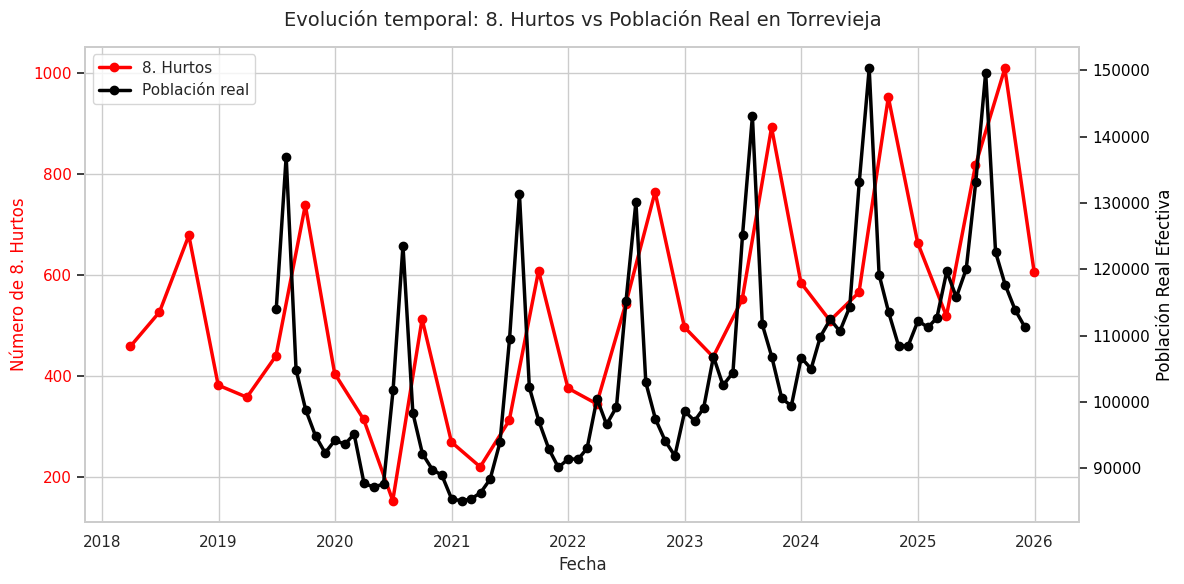

In [ ]:
df_criminalidad['Fecha_Fin_Trimestre'] = pd.to_datetime(df_criminalidad['Fecha_Fin_Trimestre'], errors='coerce')
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'], errors='coerce').dt.tz_localize(None)

# Filtro de datos
delito_objetivo = "8. Hurtos"
df_delito = df_criminalidad[df_criminalidad['Tipología penal'] == delito_objetivo]

fig, ax1 = plt.subplots(figsize=(12, 6))

# EJE IZQUIERDO (Criminalidad)
color_delito = 'red'
ax1.set_xlabel('Fecha')
ax1.set_ylabel(f'Número de {delito_objetivo}', color=color_delito)
ax1.plot(df_delito['Fecha_Fin_Trimestre'], df_delito['Total_Casos'],
         color=color_delito, linewidth=2.5, marker='o', linestyle='-', label=delito_objetivo)
ax1.tick_params(axis='y', labelcolor=color_delito)

# EJE DERECHO (Población Real)
ax2 = ax1.twinx()
color_pob = 'black'
ax2.set_ylabel('Población Real Efectiva', color=color_pob)
ax2.plot(df_poblacion_real['fecha'], df_poblacion_real['poblacion_real'],
         color=color_pob, linewidth=2.5, marker='o', linestyle='-', label='Población real')
ax2.tick_params(axis='y', labelcolor=color_pob)

plt.title(f'Evolución temporal: {delito_objetivo} vs Población Real en Torrevieja', fontsize=14, pad=15)

fig.tight_layout()

ax1.grid(True)
ax2.grid(False)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

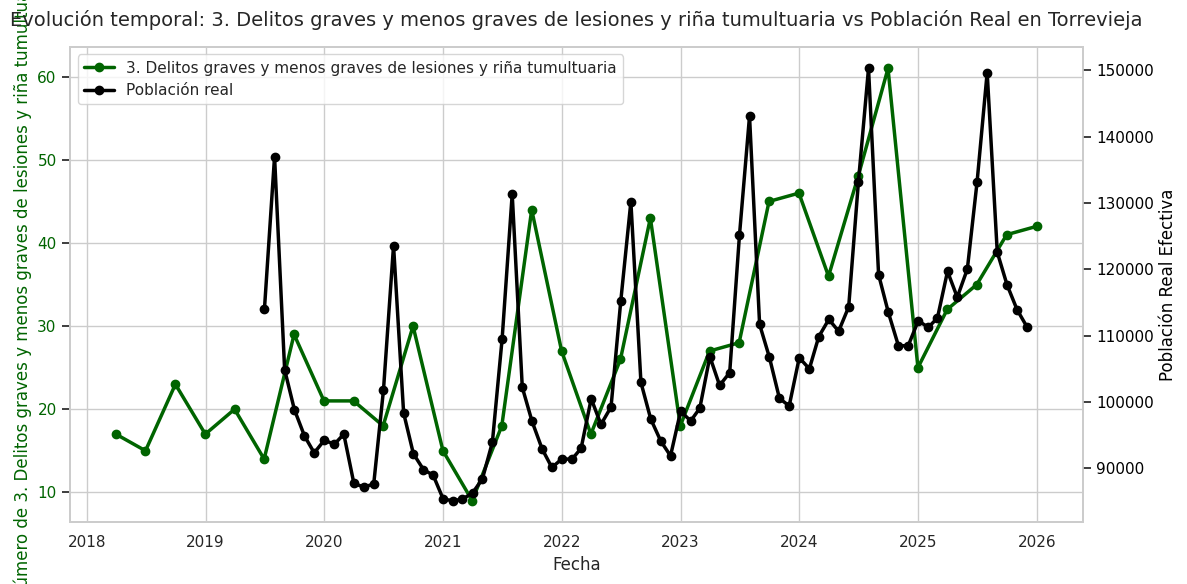

In [ ]:
df_criminalidad['Fecha_Fin_Trimestre'] = pd.to_datetime(df_criminalidad['Fecha_Fin_Trimestre'], errors='coerce')
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'], errors='coerce').dt.tz_localize(None)

# Filtro de datos
delito_objetivo = "3. Delitos graves y menos graves de lesiones y riña tumultuaria"
df_delito = df_criminalidad[df_criminalidad['Tipología penal'] == delito_objetivo]

fig, ax1 = plt.subplots(figsize=(12, 6))

# EJE IZQUIERDO (Delitos graves y menos graves de lesiones y riña tumultuaria)
color_delito = 'darkgreen'
ax1.set_xlabel('Fecha')
ax1.set_ylabel(f'Número de {delito_objetivo}', color=color_delito)
ax1.plot(df_delito['Fecha_Fin_Trimestre'], df_delito['Total_Casos'],
         color=color_delito, linewidth=2.5, marker='o', linestyle='-', label=delito_objetivo)
ax1.tick_params(axis='y', labelcolor=color_delito)

# EJE DERECHO (Población Real)
ax2 = ax1.twinx()
color_pob = 'black'
ax2.set_ylabel('Población Real Efectiva', color=color_pob)
ax2.plot(df_poblacion_real['fecha'], df_poblacion_real['poblacion_real'],
         color=color_pob, linewidth=2.5, marker='o', linestyle='-', label='Población real')
ax2.tick_params(axis='y', labelcolor=color_pob)

plt.title(f'Evolución temporal: {delito_objetivo} vs Población Real en Torrevieja', fontsize=14, pad=15)

fig.tight_layout()

ax1.grid(True)
ax2.grid(False)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

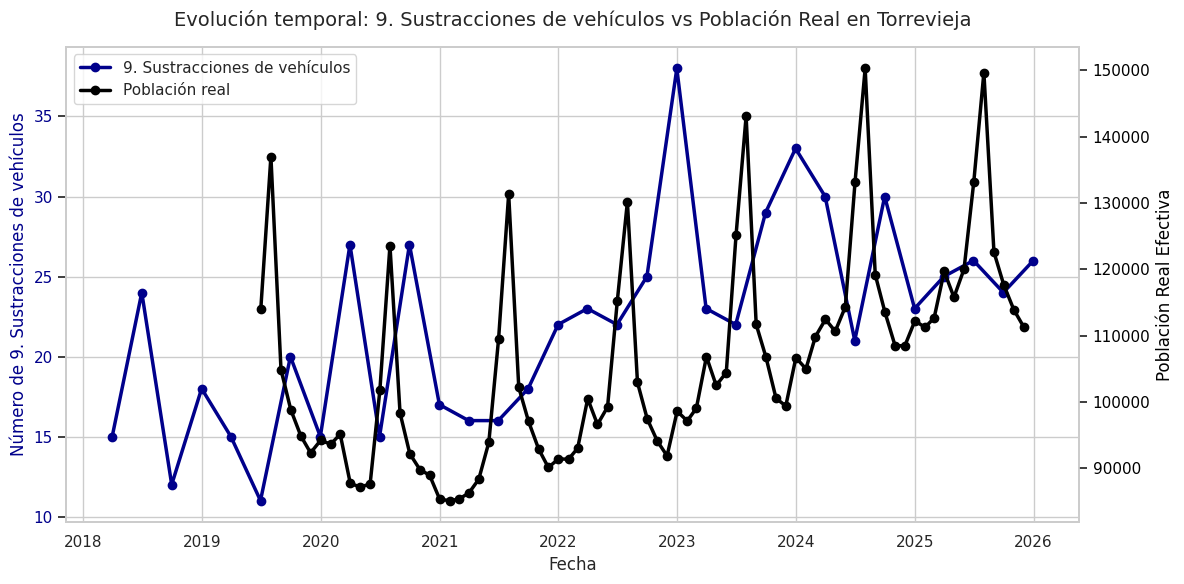

In [ ]:
df_criminalidad['Fecha_Fin_Trimestre'] = pd.to_datetime(df_criminalidad['Fecha_Fin_Trimestre'], errors='coerce')
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'], errors='coerce').dt.tz_localize(None)

# Filtro de datos
delito_objetivo = "9. Sustracciones de vehículos"
df_delito = df_criminalidad[df_criminalidad['Tipología penal'] == delito_objetivo]

fig, ax1 = plt.subplots(figsize=(12, 6))

# EJE IZQUIERDO (Sustracciones de vehículos)
color_delito = 'darkblue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel(f'Número de {delito_objetivo}', color=color_delito)
ax1.plot(df_delito['Fecha_Fin_Trimestre'], df_delito['Total_Casos'],
         color=color_delito, linewidth=2.5, marker='o', linestyle='-', label=delito_objetivo)
ax1.tick_params(axis='y', labelcolor=color_delito)

# EJE DERECHO (Población Real)
ax2 = ax1.twinx()
color_pob = 'black'
ax2.set_ylabel('Población Real Efectiva', color=color_pob)
ax2.plot(df_poblacion_real['fecha'], df_poblacion_real['poblacion_real'],
         color=color_pob, linewidth=2.5, marker='o', linestyle='-', label='Población real')
ax2.tick_params(axis='y', labelcolor=color_pob)

plt.title(f'Evolución temporal: {delito_objetivo} vs Población Real en Torrevieja', fontsize=14, pad=15)

fig.tight_layout()

ax1.grid(True)
ax2.grid(False)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

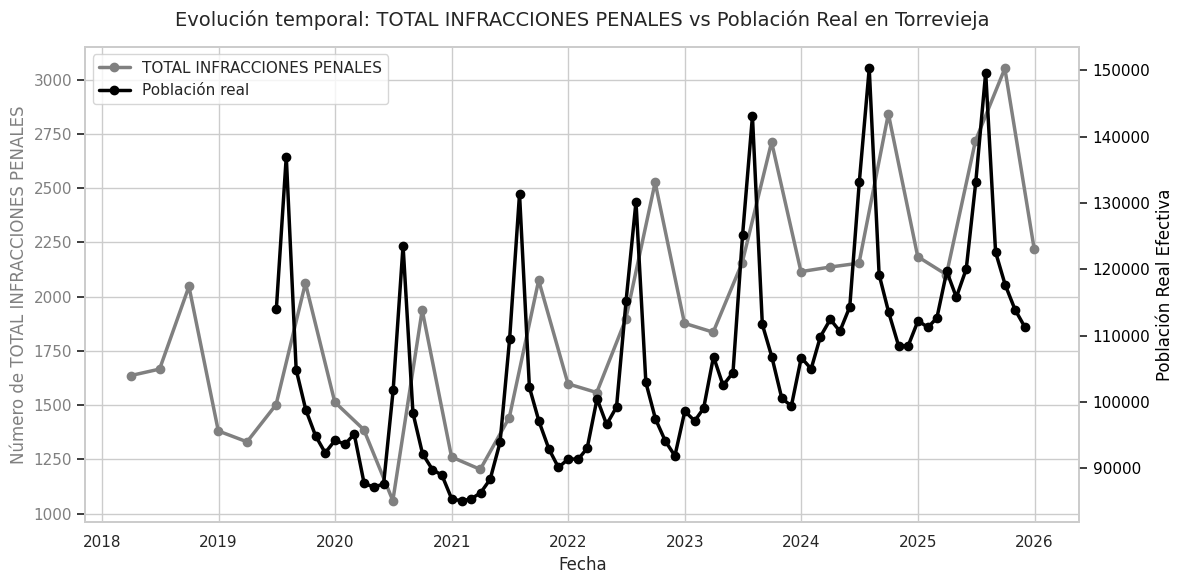

In [ ]:
df_criminalidad['Fecha_Fin_Trimestre'] = pd.to_datetime(df_criminalidad['Fecha_Fin_Trimestre'], errors='coerce')
df_poblacion_real['fecha'] = pd.to_datetime(df_poblacion_real['fecha'], errors='coerce').dt.tz_localize(None)

# Filtro de datos
delito_objetivo = "TOTAL INFRACCIONES PENALES"
df_delito = df_criminalidad[df_criminalidad['Tipología penal'] == delito_objetivo]

fig, ax1 = plt.subplots(figsize=(12, 6))

# EJE IZQUIERDO (TOTAL INFRACCIONES PENALES)
color_delito = 'grey'
ax1.set_xlabel('Fecha')
ax1.set_ylabel(f'Número de {delito_objetivo}', color=color_delito)
ax1.plot(df_delito['Fecha_Fin_Trimestre'], df_delito['Total_Casos'],
         color=color_delito, linewidth=2.5, marker='o', linestyle='-', label=delito_objetivo)
ax1.tick_params(axis='y', labelcolor=color_delito)

# EJE DERECHO (Población Real)
ax2 = ax1.twinx()
color_pob = 'black'
ax2.set_ylabel('Población Real Efectiva', color=color_pob)
ax2.plot(df_poblacion_real['fecha'], df_poblacion_real['poblacion_real'],
         color=color_pob, linewidth=2.5, marker='o', linestyle='-', label='Población real')
ax2.tick_params(axis='y', labelcolor=color_pob)

plt.title(f'Evolución temporal: {delito_objetivo} vs Población Real en Torrevieja', fontsize=14, pad=15)

fig.tight_layout()
ax1.grid(True)
ax2.grid(False)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')